# 01 — Exploratory Data Analysis: the Nepanglish labeled corpus

Everything labeled in the harness so far, read straight from the four dataset exports and
profiled on all available CPU cores.

**What this notebook is for.** The corpus is small and expensive, so the questions worth asking
of it are not "what does the data look like" but:

1. **How much is there, and of what?** Hours, episodes, splits, and how far the two pots are from
   their targets.
2. **What did labeling actually do?** The edit rate is the number everything downstream depends
   on — it is the ceiling on how much of the queue can ever be auto-approved.
3. **Is the corpus code-switched enough to be worth building?** CMI at the segment and token level.
4. **Which strata are thin?** The gold pot is meant to span speakers, genres and topics, not just
   accumulate hours.
5. **How good are the three ASR systems on human reference,** overall and where the code-switching
   is dense.
6. **Does cross-ASR disagreement predict a human edit** well enough to gate pseudo-labels?
7. **Does the seed system anchor the annotator?** If it does, the benchmark is contaminated.

**Parallelism.** Every expensive step — JSONL parsing, checksum verification, token profiling,
Levenshtein WER/CER, and the bootstraps — fans out over processes with `joblib`, with the
numeric libraries pinned to one thread per worker so the two layers do not oversubscribe the box.
Each such cell prints its wall time and, where a serial baseline is cheap enough to measure, the
speedup it bought. At 11 hours of audio the absolute times are small — the point of the layout is
that it does not need rewriting when the corpus grows into the ~2,400-hour archive behind it.

**Running it.** The environment is `notebooks/requirements.txt`, deliberately separate from the
backend's — the harness image must not grow a pandas dependency. The data comes from the four
dataset exports:

```bash
python scripts/export_dataset.py --kind all      # writes exports/{analytics,training,gold,error_mining}/

uv venv --python 3.13 notebooks/.venv
VIRTUAL_ENV=notebooks/.venv uv pip install -r notebooks/requirements.txt
notebooks/.venv/bin/python -m ipykernel install --user \
    --name labeling-harness-eda --display-name "labeling-harness (EDA)"
```

**Provenance.** The exports are produced by `scripts/export_dataset.py` and carry a manifest with
the git commit, the label and policy versions, and a SHA-256 per file. Section 2 verifies those
checksums before anything is read, so a stale or truncated export fails loudly here rather than
quietly skewing a number further down.

## 1. Environment and parallel setup

In [1]:
import os

# Pin the numeric libraries to a single thread each *before* numpy is imported. Every heavy step
# below fans out with joblib over processes; letting BLAS and OpenMP fan out again inside each
# worker oversubscribes the machine and makes the parallel version slower than the serial one.
for _var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ.setdefault(_var, "1")

import hashlib
import json
import re
import time
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
from joblib import Parallel, cpu_count, delayed
from rapidfuzz.distance import Levenshtein

N_JOBS = cpu_count()

#: One reused pool. loky caches its executor, so the workers are spawned once for the whole
#: notebook rather than once per parallel section.
POOL = Parallel(n_jobs=N_JOBS, backend="loky")

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

_style = "seaborn-v0_8-whitegrid"
plt.style.use(_style if _style in plt.style.available else "default")
plt.rcParams.update({"font.size": 10, "figure.autolayout": True, "figure.dpi": 110})

# Some episode ids are Devanagari and matplotlib does not chain font families per glyph: whichever
# family resolves first renders every character, so a Latin default draws Devanagari as empty
# boxes and a Devanagari font draws Latin as empty boxes. Tick labels are therefore given their
# font one at a time, by script.
_installed = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
DEVA_FONT = next(
    (n for n in ("Noto Sans Devanagari", "Noto Serif Devanagari", "FreeSans") if n in _installed),
    None,
)
DEVANAGARI = re.compile(r"[ऀ-ॿ]")


def script_aware_ticklabels(ax, axis, labels, **kwargs):
    """Set tick labels, switching to a Devanagari face for the ones that need it."""
    setter = ax.set_yticklabels if axis == "y" else ax.set_xticklabels
    texts = setter(labels, **kwargs)
    if DEVA_FONT:
        for text in texts:
            if DEVANAGARI.search(text.get_text()):
                text.set_fontfamily(DEVA_FONT)
    return texts

#: Ordered so a system keeps the same colour in every figure.
SYSTEMS = ["elevenlabs-scribe-v2", "gemini-3.8-flash", "mai-transcribe-2"]
SYS_COLOR = dict(zip(SYSTEMS, ["#2563eb", "#d97706", "#059669"]))
POT_COLOR = {"gold": "#b45309", "train": "#2563eb", "unassigned": "#9ca3af"}

REPO_ROOT = Path("..").resolve() if Path("../exports").is_dir() else Path(".").resolve()
EXPORT_ROOT = REPO_ROOT / "exports"
FIG_DIR = REPO_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Write a figure to notebooks/figures/ and report where it went."""
    path = FIG_DIR / f"eda_{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  figure -> {path.relative_to(REPO_ROOT)}")


def timed(label, seconds, extra=""):
    """Uniform one-line timing report for the parallel sections."""
    print(f"  [{label}] {seconds:.2f}s{(' — ' + extra) if extra else ''}")


print(f"CPU cores available   : {N_JOBS}")
print(f"joblib backend        : loky, {N_JOBS} worker processes, 1 BLAS thread each")
print(f"repository root       : {REPO_ROOT}")
print(f"export root           : {EXPORT_ROOT}")
print(f"Devanagari face      : {DEVA_FONT or 'NONE INSTALLED — Devanagari labels will not render'}")
print(f"pandas {pd.__version__} / numpy {np.__version__} / matplotlib {plt.matplotlib.__version__}")

CPU cores available   : 16
joblib backend        : loky, 16 worker processes, 1 BLAS thread each
repository root       : /home/sagyam/Projects/labeling-harness
export root           : /home/sagyam/Projects/labeling-harness/exports
Devanagari face      : Noto Sans Devanagari
pandas 3.0.5 / numpy 2.5.3 / matplotlib 3.11.1


## 2. Export provenance and integrity

Four export kinds are written by `scripts/export_dataset.py`, each with a manifest recording the
filters it applied, the git commit that produced it, and a SHA-256 per file. `analytics` is the
superset this notebook works from — every labeled row, including the ones a training export drops,
with per-hypothesis and per-word fields attached.

The checksums are recomputed in parallel and compared. If one disagrees, stop: the numbers below
would be describing a file that is not the one the manifest documents.

In [2]:
KINDS = ["analytics", "training", "gold", "error_mining"]

manifests = {}
for kind in KINDS:
    manifest_path = EXPORT_ROOT / kind / "manifest.json"
    if manifest_path.is_file():
        manifests[kind] = json.loads(manifest_path.read_text(encoding="utf-8"))

if "analytics" not in manifests:
    raise SystemExit(
        "no analytics export found — run:  python scripts/export_dataset.py --kind all"
    )


def sha256_of(path):
    """Stream a file through SHA-256; returns (path, digest) so results can be reordered."""
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1 << 20), b""):
            digest.update(block)
    return str(path), digest.hexdigest()


wanted = {}
for kind, manifest in manifests.items():
    for entry in manifest["files"]:
        wanted[str(EXPORT_ROOT / kind / entry["name"])] = (kind, entry["name"], entry["sha256"])

t0 = time.perf_counter()
computed = dict(POOL(delayed(sha256_of)(Path(p)) for p in wanted))
elapsed = time.perf_counter() - t0
total_bytes = sum(Path(p).stat().st_size for p in wanted)
timed("sha256", elapsed, f"{len(wanted)} files, {total_bytes / 1e6:.1f} MB over {N_JOBS} workers")

integrity = pd.DataFrame(
    [
        {
            "kind": kind,
            "file": name,
            "MB": round(Path(path).stat().st_size / 1e6, 2),
            "rows": manifests[kind]["row_count"],
            "sha256_ok": computed[path] == expected,
        }
        for path, (kind, name, expected) in sorted(wanted.items())
    ]
)
assert integrity["sha256_ok"].all(), integrity[~integrity["sha256_ok"]]
display(integrity)

am = manifests["analytics"]
print(f"exported_at           : {am['exported_at']}")
print(f"git commit            : {am['git_commit']}")
print(f"label / policy version: {am['label_version']} / {am['policy_version']}")
print(f"normalization version : {am.get('normalization_version')}")
print(f"import runs behind it : {len(am['import_runs'])}")
print(f"rows by split         : {am['row_counts_by_split']}")
print(f"verification tiers    : {am['verification_tiers_by_split']}")

  [sha256] 1.19s — 66 files, 5774.0 MB over 16 workers


,kind,file,MB,rows,sha256_ok
0,analytics,analytics.jsonl,79.1100,4797,True
1,analytics,episodes/_.flac,13.4300,4797,True
2,analytics,episodes/ashima_poudyal_into_aroma_9_5_job_int...,164.9800,4797,True
3,analytics,episodes/best_burger_in_ktm.flac,30.3800,4797,True
4,analytics,episodes/claude_for_beginners_in_nepal.flac,263.6300,4797,True
...,...,...,...,...,...
61,training,episodes/the_bravo_delta_show_season_3_ep_2_bh...,97.8800,3858,True
62,training,episodes/they_thought_they_were_cheap_but_were...,56.3700,3858,True
63,training,episodes/when_i_said_i_wanted_to_study_you_sup...,51.6700,3858,True
64,training,episodes/why_do_they_keep_talking_nonsense.flac,49.5400,3858,True


exported_at           : 2026-09-08T12:28:11.719630+00:00
git commit            : 30e916ec590147c32b50bbe919b9ebb391b0fa11
label / policy version: v1 / policy_v1
normalization version : norm-v3
import runs behind it : 28
rows by split         : {'test': 928, 'train': 3791, 'val': 78}
verification tiers    : {'test': {'verified': 928}, 'train': {'screened': 1191, 'verified': 2600}, 'val': {'screened': 16, 'verified': 62}}


## 3. Parallel load

`analytics.jsonl` is one JSON object per labeled segment, each carrying three ASR hypotheses and
their word lists — roughly 350,000 word objects in total, which is what makes a single-threaded
`json.loads` loop the slowest step in the notebook.

The file is split into byte ranges snapped forward to the next newline, one per worker. Each worker
parses its range and **reduces as it goes**: it returns flat segment and hypothesis records plus
concatenated word-duration and word-confidence arrays, never the 350,000 dictionaries themselves.
That keeps the inter-process pickling proportional to the summary, not to the raw file.

In [3]:
ANALYTICS_PATH = EXPORT_ROOT / "analytics" / "analytics.jsonl"


def chunk_bounds(path, n_chunks):
    """Split a file into n byte ranges, each ending on a newline so no record is cut in half."""
    size = path.stat().st_size
    bounds, start = [], 0
    with path.open("rb") as handle:
        for index in range(1, n_chunks):
            handle.seek(size * index // n_chunks)
            handle.readline()
            position = handle.tell()
            if position > start:
                bounds.append((start, position))
                start = position
        if start < size:
            bounds.append((start, size))
    return bounds


def parse_chunk(path, start, end):
    """Parse one byte range of the analytics export into flat, already-reduced records."""
    segments, hypotheses = [], []
    word_dur, word_conf = {}, {}

    with open(path, "rb") as handle:
        handle.seek(start)
        payload = handle.read(end - start)

    for line in payload.splitlines():
        if not line.strip():
            continue
        record = json.loads(line)
        scores = record.get("scores") or {}
        meta = record.get("episode_metadata") or {}
        speakers = meta.get("speakers") or {}
        genders = sorted({s.get("gender") for s in speakers.values() if s.get("gender")})
        ages = sorted({s.get("age_bracket") for s in speakers.values() if s.get("age_bracket")})

        segments.append(
            {
                "segment_id": record["segment_id"],
                "episode_id": record["episode_id"],
                "split": record["split"],
                "pot": record["pot"],
                "disposition": record["disposition"],
                "verification_tier": record["verification_tier"],
                "seed_system_id": record.get("seed_system_id"),
                "start_time": record.get("start_time"),
                "end_time": record.get("end_time"),
                "duration_seconds": record.get("duration_seconds"),
                "text": record.get("text") or "",
                "notes": record.get("notes"),
                "speaker_id": record.get("speaker_id"),
                "code_switch_density": record.get("code_switch_density"),
                "cer_between_hypotheses": scores.get("cer_between_hypotheses"),
                "word_disagreement_rate": scores.get("word_disagreement_rate"),
                "script_conflict_rate": scores.get("script_conflict_rate"),
                "flags": list(scores.get("flags") or []),
                "genre": meta.get("genre"),
                "topic": meta.get("topic"),
                "topic_source": meta.get("topic_source"),
                "n_speakers": len(speakers),
                "gender_mix": "mixed" if len(genders) > 1 else (genders[0] if genders else None),
                "age_mix": "mixed" if len(ages) > 1 else (ages[0] if ages else None),
                "label_version": record.get("label_version"),
                "policy_version": record.get("policy_version"),
            }
        )

        for hypothesis in record.get("hypotheses") or []:
            system = hypothesis["system_id"]
            words = hypothesis.get("words") or []
            durations = [
                w["end"] - w["start"]
                for w in words
                if w.get("start") is not None and w.get("end") is not None
            ]
            confidences = [w["confidence"] for w in words if w.get("confidence") is not None]
            word_dur.setdefault(system, []).extend(durations)
            word_conf.setdefault(system, []).extend(confidences)
            hypotheses.append(
                {
                    "segment_id": record["segment_id"],
                    "system_id": system,
                    "model_id": hypothesis.get("model_id"),
                    "text": hypothesis.get("text") or "",
                    "avg_logprob": hypothesis.get("avg_logprob"),
                    "no_speech_prob": hypothesis.get("no_speech_prob"),
                    "n_words": len(words),
                    # Total time the words themselves cover, for comparison with clip duration:
                    # a large shortfall is the shape of a hypothesis that stopped early.
                    "word_span_seconds": float(sum(durations)),
                    "last_word_end": max((w["end"] for w in words if w.get("end")), default=None),
                    "mean_word_conf": (
                        float(np.mean(confidences)) if confidences else float("nan")
                    ),
                }
            )

    return {
        "segments": segments,
        "hypotheses": hypotheses,
        "word_dur": {k: np.asarray(v, dtype="float32") for k, v in word_dur.items()},
        "word_conf": {k: np.asarray(v, dtype="float32") for k, v in word_conf.items()},
    }


bounds = chunk_bounds(ANALYTICS_PATH, N_JOBS)
t0 = time.perf_counter()
parts = POOL(delayed(parse_chunk)(str(ANALYTICS_PATH), lo, hi) for lo, hi in bounds)
parallel_seconds = time.perf_counter() - t0

t0 = time.perf_counter()
_serial = parse_chunk(str(ANALYTICS_PATH), 0, ANALYTICS_PATH.stat().st_size)
serial_seconds = time.perf_counter() - t0

seg_records = [row for part in parts for row in part["segments"]]
hyp_records = [row for part in parts for row in part["hypotheses"]]
WORD_DUR = {
    system: np.concatenate([p["word_dur"][system] for p in parts if system in p["word_dur"]])
    for system in SYSTEMS
}
WORD_CONF = {
    system: np.concatenate([p["word_conf"][system] for p in parts if system in p["word_conf"]])
    for system in SYSTEMS
}
n_words = sum(len(v) for v in WORD_DUR.values())

assert len(seg_records) == len(_serial["segments"]), "chunking lost or duplicated a record"
timed(
    "load",
    parallel_seconds,
    f"{len(seg_records):,} segments, {len(hyp_records):,} hypotheses, {n_words:,} words "
    f"across {len(bounds)} chunks",
)
print(f"  serial baseline: {serial_seconds:.2f}s  ->  speedup {serial_seconds / parallel_seconds:.1f}x")
del _serial

  [load] 0.11s — 4,797 segments, 14,391 hypotheses, 448,377 words across 16 chunks
  serial baseline: 0.63s  ->  speedup 5.5x


In [4]:
seg = pd.DataFrame(seg_records).set_index("segment_id").sort_index()
hyp = pd.DataFrame(hyp_records).sort_values(["segment_id", "system_id"], ignore_index=True)

seg["is_edited"] = (seg["disposition"] == "edited").astype(int)
seg["is_screened"] = (seg["verification_tier"] == "screened").astype(int)
seg["cmi_pct"] = seg["code_switch_density"] * 100.0
seg["n_flags"] = seg["flags"].str.len()
for flag in sorted({f for flags in seg["flags"] for f in flags}):
    seg[f"flag_{flag}"] = seg["flags"].apply(lambda flags, f=flag: f in flags).astype(int)

print(f"segments      {len(seg):,} rows x {seg.shape[1]} columns")
print(f"hypotheses    {len(hyp):,} rows ({len(hyp) / max(len(seg), 1):.1f} per segment)")
print()
print("Columns that are entirely empty (nothing downstream can use these yet):")
empty = [c for c in seg.columns if seg[c].isna().all() or (seg[c] == "").all()]
print("  " + (", ".join(empty) if empty else "none"))
print()
print("Missingness where it is partial:")
missing = seg.isna().mean().mul(100).round(2)
display(missing[(missing > 0) & (missing < 100)].sort_values(ascending=False).to_frame("% null"))
display(seg.head(3))

segments      4,797 rows x 33 columns
hypotheses    14,391 rows (3.0 per segment)

Columns that are entirely empty (nothing downstream can use these yet):
  notes, script_conflict_rate

Missingness where it is partial:


,% null
topic_source,32.2700


,episode_id,split,pot,disposition,verification_tier,seed_system_id,start_time,end_time,duration_seconds,text,notes,speaker_id,code_switch_density,cer_between_hypotheses,word_disagreement_rate,script_conflict_rate,flags,genre,topic,topic_source,n_speakers,gender_mix,age_mix,label_version,policy_version,is_edited,is_screened,cmi_pct,n_flags,flag_empty_transcript,flag_missed_speech,flag_repeated_ngram,flag_script_conflict
segment_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
__00001,_,train,train,accepted_unchanged,verified,elevenlabs-scribe-v2,19.7690,38.1900,18.4210,"चार सँगसँगै यसको salad बनाउन सक्नुहुन्छ, यसको ...",None,spk0,0.1220,0.2605,0.2194,None,[],cooking,travel_food,llm,1,female,40_59,v1,policy_v1,0,0,12.2000,0,0,0,0,0
__00002,_,train,train,edited,verified,mai-transcribe-2,38.1900,58.1900,20.0000,सुरुमा मैले लिएकी छु दुईटा avocado। हजुरहरूले ...,None,spk0,0.0508,0.2182,0.2482,None,[],cooking,travel_food,llm,1,female,40_59,v1,policy_v1,1,0,5.0800,0,0,0,0,0
__00003,_,train,train,accepted_unchanged,verified,elevenlabs-scribe-v2,58.1900,76.6620,18.4720,"सुन, यहाँ चाहिँ मैले थोरै तिमुर पनि लिएकी छु। ...",None,spk0,0.1132,0.0662,0.1965,None,[],cooking,travel_food,llm,1,female,40_59,v1,policy_v1,0,0,11.3200,0,0,0,0,0


`speaker_id` is `spk0` on every row and carries no identity: the pipeline segments before it
transcribes, so a clip almost always holds one speaker and `spk0` in one clip is not `spk0` in the
next (D52). Speaker-level analysis below therefore comes from the **episode** metadata, never from
this column.

## 4. Corpus shape: how much, of what, and how far from target

`config/settings.yaml` states the targets in **hours, not ratios** (D63) — a ratio over episode
count cannot express "five hours of benchmark audio" when episodes run from minutes to hours. The
train target was cut from 50 h to ~20 h because the from-scratch scaling curve behind 50 h does not
apply to domain adaptation on a pretrained model, and because the binding constraint is speakers,
not hours. Both readings are below.

In [5]:
import yaml

settings = yaml.safe_load((REPO_ROOT / "config" / "settings.yaml").read_text(encoding="utf-8"))
targets = settings["dataset"]

seg["hours"] = seg["duration_seconds"] / 3600.0
total_hours = seg["hours"].sum()

by_pot = (
    seg.groupby("pot")
    .agg(
        segments=("hours", "size"),
        hours=("hours", "sum"),
        episodes=("episode_id", "nunique"),
        mean_seconds=("duration_seconds", "mean"),
        edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
        screened_pct=("is_screened", lambda s: 100 * s.mean()),
    )
    .assign(
        target_hours=lambda d: [
            targets["gold_hours_target"] if p == "gold" else targets["train_hours_target"]
            for p in d.index
        ]
    )
)
by_pot["pct_of_target"] = 100 * by_pot["hours"] / by_pot["target_hours"]
by_pot["corpus_share_pct"] = 100 * by_pot["hours"] / total_hours

print(f"Labeled corpus: {len(seg):,} segments, {total_hours:.2f} hours, "
      f"{seg['episode_id'].nunique()} episodes")
print(f"Mean clip {seg['duration_seconds'].mean():.1f}s, "
      f"median {seg['duration_seconds'].median():.1f}s, "
      f"max {seg['duration_seconds'].max():.1f}s "
      f"(segmenter cap is MAX_SEG_SECONDS = 20.0s)")
display(by_pot)

gold_share = by_pot.loc["gold", "corpus_share_pct"] if "gold" in by_pot.index else 0.0
print(f"Gold holds {gold_share:.1f}% of the labeled corpus; "
      f"the cap is {100 * targets['gold_max_corpus_fraction']:.0f}%.")
print(f"Remaining to target: gold {max(0.0, targets['gold_hours_target'] - by_pot.get('hours', {}).get('gold', 0)):.2f} h, "
      f"train {max(0.0, targets['train_hours_target'] - by_pot.get('hours', {}).get('train', 0)):.2f} h")

Labeled corpus: 4,797 segments, 15.49 hours, 28 episodes
Mean clip 11.6s, median 12.2s, max 20.3s (segmenter cap is MAX_SEG_SECONDS = 20.0s)


,segments,hours,episodes,mean_seconds,edit_rate_pct,screened_pct,target_hours,pct_of_target,corpus_share_pct
pot,,,,,,,,,
gold,928,2.7979,5,10.8540,18.8578,0.0000,3.0000,93.2638,18.0627
train,3869,12.6921,23,11.8097,17.6273,31.1967,20.0000,63.4605,81.9373


Gold holds 18.1% of the labeled corpus; the cap is 35%.
Remaining to target: gold 0.20 h, train 7.31 h


,pot,split,genre,topic,n_speakers,gender_mix,age_mix,segments,hours,edit_rate_pct,screened_pct,mean_cmi_pct
episode_id,,,,,,,,,,,,
ep_623_is_the_current_global_conflict_th,train,train,podcast,news_current_affairs,3,male,mixed,888,2.4798,23.4234,63.2883,20.8408
ep_602_do_higher_traffic_fines_reduce_ro,train,train,podcast,politics_governance,2,male,mixed,636,2.3622,20.7547,0.0000,26.1443
claude_for_beginners_in_nepal,train,train,podcast,technology,2,male,20_39,551,1.9492,27.7677,0.0000,33.6995
ep_612_manisha_koirala_monarchy_politics,train,train,podcast,personal_story,2,mixed,mixed,390,1.2274,6.4103,35.1282,13.9691
हमलयन_जभक_२६_वरष_सघरष_र_सफलतक_कथ,gold,test,interview,business_finance,1,male,40_59,263,0.9693,15.9696,0.0000,25.2359
ashima_poudyal_into_aroma_9_5_job_into_e,train,train,podcast,business_finance,2,female,20_39,186,0.7597,3.7634,60.2151,33.6623
minister_mahabir_pun_unfiltered_with_bik,gold,test,podcast,politics_governance,2,male,mixed,282,0.7353,9.2199,0.0000,2.5722
mailo_bajeko_kalo_maya_herne_katha_ep158,gold,test,documentary,personal_story,2,mixed,mixed,299,0.7239,25.0836,0.0000,4.6647
the_bravo_delta_show_season_3_ep_2_bhusa,train,train,podcast,health_wellness,2,mixed,mixed,150,0.4411,4.6667,58.6667,20.5917


  figure -> notebooks/figures/eda_01_corpus_shape.png


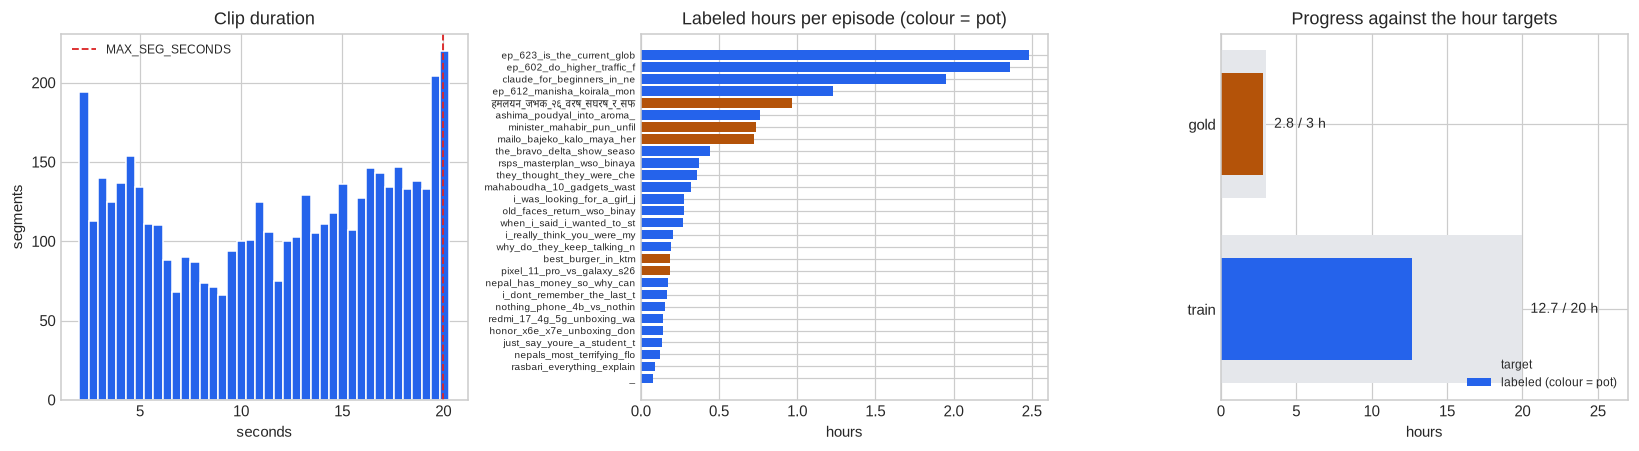

In [6]:
episodes = (
    seg.groupby("episode_id")
    .agg(
        pot=("pot", "first"),
        split=("split", "first"),
        genre=("genre", "first"),
        topic=("topic", "first"),
        n_speakers=("n_speakers", "first"),
        gender_mix=("gender_mix", "first"),
        age_mix=("age_mix", "first"),
        segments=("hours", "size"),
        hours=("hours", "sum"),
        edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
        screened_pct=("is_screened", lambda s: 100 * s.mean()),
        mean_cmi_pct=("cmi_pct", "mean"),
    )
    .sort_values("hours", ascending=False)
)
display(episodes)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(seg["duration_seconds"].dropna(), bins=40, color="#2563eb", edgecolor="white")
axes[0].axvline(20.0, color="#dc2626", ls="--", lw=1.2, label="MAX_SEG_SECONDS")
axes[0].set(title="Clip duration", xlabel="seconds", ylabel="segments")
axes[0].legend(fontsize=8)

order = episodes.sort_values("hours")
axes[1].barh(
    range(len(order)),
    order["hours"],
    color=[POT_COLOR.get(p, "#9ca3af") for p in order["pot"]],
)
axes[1].set_yticks(range(len(order)))
script_aware_ticklabels(axes[1], "y", [e[:26] for e in order.index], fontsize=6.5)
axes[1].set(title="Labeled hours per episode (colour = pot)", xlabel="hours")

pot_hours = by_pot["hours"].reindex(["train", "gold"]).fillna(0)
pot_target = by_pot["target_hours"].reindex(["train", "gold"]).fillna(0)
ypos = np.arange(len(pot_hours))
axes[2].barh(ypos, pot_target, color="#e5e7eb", label="target")
axes[2].barh(ypos, pot_hours, height=0.55,
             color=[POT_COLOR.get(p, "#9ca3af") for p in pot_hours.index], label="labeled")
for y, (have, want) in enumerate(zip(pot_hours, pot_target)):
    axes[2].text(want, y, f"  {have:.1f} / {want:.0f} h", va="center", fontsize=9)
axes[2].set_yticks(ypos)
axes[2].set_yticklabels(pot_hours.index)
axes[2].set(title="Progress against the hour targets", xlabel="hours")
axes[2].set_xlim(0, float(pot_target.max()) * 1.35)
axes[2].legend(["target", "labeled (colour = pot)"], fontsize=8, loc="lower right")

save_fig(fig, "01_corpus_shape")
plt.show()

## 5. What labeling actually did

Three numbers matter here and they are easy to conflate:

- **disposition** — what the annotator decided (`accepted_unchanged`, `edited`, `uncertain`).
- **verification_tier** — how hard they looked. `verified` means played and read; `screened` means
  accepted on the cross-ASR disagreement signal without listening. A screened row is a weaker claim
  and the gold export refuses to contain one at all (D63).
- **edit rate** — the share of segments the seed hypothesis got wrong enough to be corrected. This
  is the ceiling on auto-approval: no amount of ranking can push the auto-approved share above
  `1 - edit_rate` without approving segments a human would have edited.

verification_tier,screened,verified,All
disposition,,,
accepted_unchanged,1207,2721,3928
edited,0,857,857
uncertain,0,8,8
unusable_audio,0,4,4
All,1207,3590,4797


Base edit rate, all rows      : 17.9%
Base edit rate, verified only : 23.9%  (n=3,590) — the honest figure; screened rows were never listened to,
                                so their 'accepted' is not evidence the hypothesis was right.
Screened share of the corpus  : 25.2%

Auto-approval ceiling implied by the verified edit rate: 76.1% of the queue.


segments  hours  edit_rate_pct
pot   verification_tier                                
gold  verified                928 2.7979        18.8578
train screened               1207 3.9995         0.0000
      verified               2662 8.6926        25.6198

  figure -> notebooks/figures/eda_02_labeling_process.png


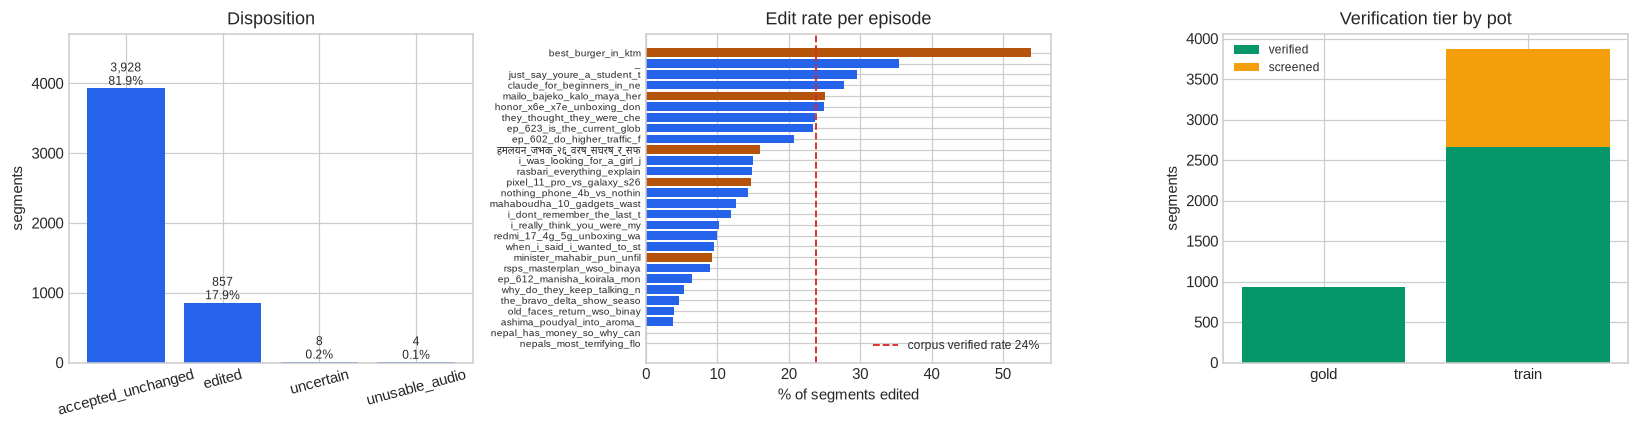

In [7]:
crosstab = pd.crosstab(seg["disposition"], seg["verification_tier"], margins=True)
display(crosstab)

base_edit_rate = seg["is_edited"].mean()
verified = seg[seg["verification_tier"] == "verified"]
verified_edit_rate = verified["is_edited"].mean()

print(f"Base edit rate, all rows      : {100 * base_edit_rate:.1f}%")
print(f"Base edit rate, verified only : {100 * verified_edit_rate:.1f}%  "
      f"(n={len(verified):,}) — the honest figure; screened rows were never listened to,")
print(f"{'':32}so their 'accepted' is not evidence the hypothesis was right.")
print(f"Screened share of the corpus  : {100 * seg['is_screened'].mean():.1f}%")
print()
print(f"Auto-approval ceiling implied by the verified edit rate: "
      f"{100 * (1 - verified_edit_rate):.1f}% of the queue.")

by_tier = seg.groupby(["pot", "verification_tier"]).agg(
    segments=("is_edited", "size"),
    hours=("hours", "sum"),
    edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
)
display(by_tier)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

disp_counts = seg["disposition"].value_counts()
axes[0].bar(disp_counts.index, disp_counts.values, color="#2563eb")
for x, v in enumerate(disp_counts.values):
    axes[0].text(x, v, f"{v:,}\n{100 * v / len(seg):.1f}%", ha="center", va="bottom", fontsize=8)
axes[0].set(title="Disposition", ylabel="segments")
axes[0].tick_params(axis="x", labelrotation=15)
axes[0].set_ylim(0, disp_counts.max() * 1.2)

ep_order = episodes.sort_values("edit_rate_pct")
axes[1].barh(range(len(ep_order)), ep_order["edit_rate_pct"],
             color=[POT_COLOR.get(p, "#9ca3af") for p in ep_order["pot"]])
axes[1].axvline(100 * verified_edit_rate, color="#dc2626", ls="--", lw=1.2,
                label=f"corpus verified rate {100 * verified_edit_rate:.0f}%")
axes[1].set_yticks(range(len(ep_order)))
script_aware_ticklabels(axes[1], "y", [e[:26] for e in ep_order.index], fontsize=6.5)
axes[1].set(title="Edit rate per episode", xlabel="% of segments edited")
axes[1].legend(fontsize=8)

tiers = seg.groupby(["pot", "verification_tier"]).size().unstack(fill_value=0)
bottom = np.zeros(len(tiers))
for tier, color in [("verified", "#059669"), ("screened", "#f59e0b")]:
    if tier in tiers:
        axes[2].bar(tiers.index, tiers[tier], bottom=bottom, label=tier, color=color)
        bottom = bottom + tiers[tier].values
axes[2].set(title="Verification tier by pot", ylabel="segments")
axes[2].legend(fontsize=8)

save_fig(fig, "02_labeling_process")
plt.show()

## 6. Code-mixing, measured two ways

`code_switch_density` is computed by the harness at import time on the **primary** hypothesis. The
human reference text is the better surface to measure on, so this section recomputes the mix from
the labeled transcripts directly and compares.

The token-level pass — script classification, the Code-Mixing Index per segment, and the English
insertion lexicon — runs over every reference transcript in parallel; each worker returns its own
counters and per-segment vector, and the reduction is a sum.

$$\mathrm{CMI} = 100 \times \frac{N - \max(N_{\mathrm{ne}}, N_{\mathrm{en}})}{N}$$

with $N$ the count of non-numeric tokens. A monolingual segment scores 0; a perfectly balanced
one scores 50.

In [8]:
DEV_RE = re.compile(r"[\u0900-\u097F]")
TOK_RE = re.compile(r"[A-Za-z']+|[\u0900-\u097F]+|\d+")
PUNCT_RE = re.compile(r"[.,!?;:\'\"|\u0964\u0965()\[\]{}\u2014-]")


def normalize_for_eval(text):
    """NFKC, strip punctuation, lowercase Latin, keep Devanagari as written."""
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = PUNCT_RE.sub(" ", text)
    return " ".join(t if DEV_RE.search(t) else t.lower() for t in text.split())


def profile_texts(texts):
    """Token-level script profile for a block of transcripts. Returns per-text rows and counters."""
    rows = []
    latin, dev = Counter(), Counter()
    for text in texts:
        tokens = TOK_RE.findall(unicodedata.normalize("NFKC", text or ""))
        n_dev = n_latin = n_num = 0
        for token in tokens:
            if token.isdigit():
                n_num += 1
            elif DEV_RE.search(token):
                n_dev += 1
                dev[token] += 1
            else:
                n_latin += 1
                latin[token.lower()] += 1
        n_lang = n_dev + n_latin
        cmi = 100.0 * (n_lang - max(n_dev, n_latin)) / n_lang if n_lang else 0.0
        rows.append((len(tokens), n_dev, n_latin, n_num, cmi))
    return rows, latin, dev


def blocks(values, n):
    """Split a sequence into n contiguous blocks, preserving order."""
    edges = np.linspace(0, len(values), n + 1).astype(int)
    return [values[edges[i]: edges[i + 1]] for i in range(n) if edges[i + 1] > edges[i]]


texts = seg["text"].tolist()
t0 = time.perf_counter()
results = POOL(delayed(profile_texts)(block) for block in blocks(texts, N_JOBS))
parallel_seconds = time.perf_counter() - t0
t0 = time.perf_counter()
profile_texts(texts)
serial_seconds = time.perf_counter() - t0
timed("token profile", parallel_seconds,
      f"{len(texts):,} transcripts over {N_JOBS} workers; serial {serial_seconds:.2f}s "
      f"({serial_seconds / parallel_seconds:.1f}x)")

rows = [row for part in results for row in part[0]]
LATIN_VOCAB = Counter()
DEV_VOCAB = Counter()
for _, latin, dev in results:
    LATIN_VOCAB.update(latin)
    DEV_VOCAB.update(dev)

seg[["n_tokens", "n_dev", "n_latin", "n_numeric", "cmi_ref"]] = pd.DataFrame(
    rows, index=seg.index, columns=["n_tokens", "n_dev", "n_latin", "n_numeric", "cmi_ref"]
)
seg["latin_share_pct"] = 100 * seg["n_latin"] / seg[["n_dev", "n_latin"]].sum(axis=1).replace(0, np.nan)

total_tokens = int(seg["n_tokens"].sum())
print(f"Reference transcripts: {total_tokens:,} tokens "
      f"({int(seg['n_dev'].sum()):,} Devanagari, {int(seg['n_latin'].sum()):,} Latin, "
      f"{int(seg['n_numeric'].sum()):,} numeric)")
print(f"Latin token share      : {100 * seg['n_latin'].sum() / (seg['n_dev'].sum() + seg['n_latin'].sum()):.1f}%")
print(f"Vocabulary             : {len(DEV_VOCAB):,} Devanagari types, {len(LATIN_VOCAB):,} Latin types")
print()
print(f"CMI from the reference : mean {seg['cmi_ref'].mean():.1f}, median {seg['cmi_ref'].median():.1f}")
print(f"CMI stored at import   : mean {seg['cmi_pct'].mean():.1f}, median {seg['cmi_pct'].median():.1f}")
corr = seg[["cmi_ref", "cmi_pct"]].corr().iloc[0, 1]
print(f"Correlation between the two: r = {corr:.3f}")
print()
print(f"Segments with no English at all: {100 * (seg['n_latin'] == 0).mean():.1f}%")
print(f"Segments with no Nepali at all : {100 * (seg['n_dev'] == 0).mean():.1f}% — monolingual "
      "English, which the CMI formula also scores 0")
print(f"Segments above CMI 15 (real intra-sentential mixing): {100 * (seg['cmi_ref'] > 15).mean():.1f}%")

  [token profile] 0.02s — 4,797 transcripts over 16 workers; serial 0.05s (2.5x)
Reference transcripts: 151,159 tokens (98,904 Devanagari, 51,571 Latin, 684 numeric)
Latin token share      : 34.3%
Vocabulary             : 12,249 Devanagari types, 5,997 Latin types

CMI from the reference : mean 20.3, median 20.4
CMI stored at import   : mean 20.1, median 20.0
Correlation between the two: r = 0.960

Segments with no English at all: 16.1%
Segments with no Nepali at all : 7.4% — monolingual English, which the CMI formula also scores 0
Segments above CMI 15 (real intra-sentential mixing): 60.0%


  figure -> notebooks/figures/eda_03_code_mixing.png


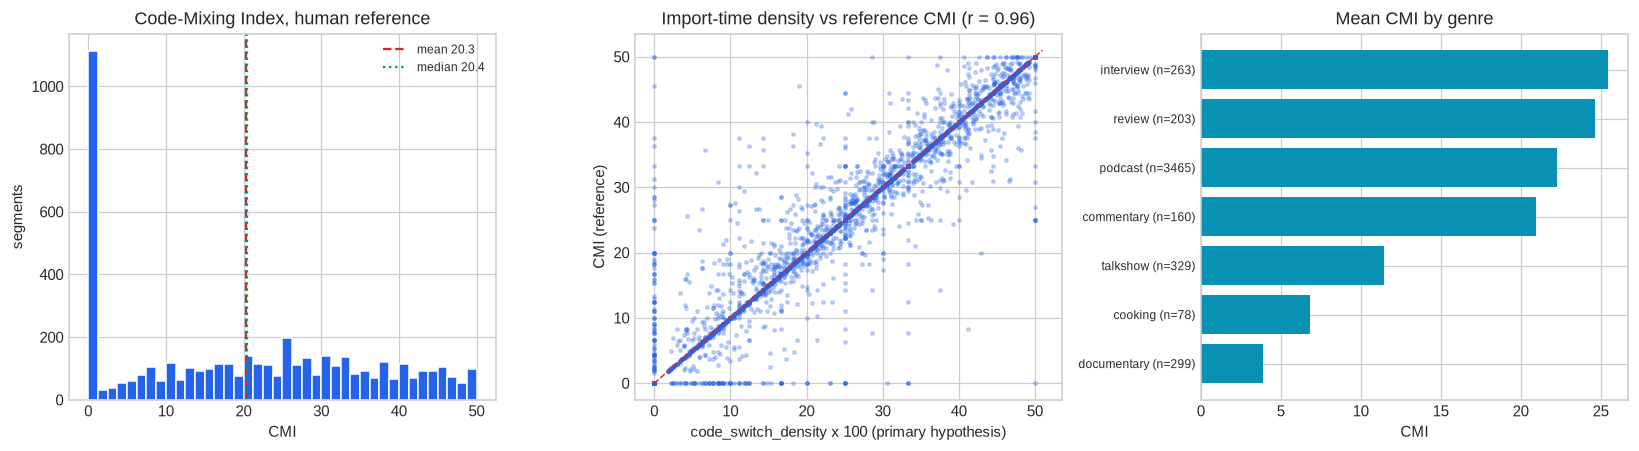

Most frequent English insertions in the human reference:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
token,i,the,so,you,to,and,a,is,of,it,that,like,we,in,this,are,think,for,one,uh,it's,time,know,what,was,okay,phone,not,but,yeah
count,1173,890,863,841,738,716,652,612,608,544,432,430,344,328,316,309,266,262,262,247,242,239,235,235,218,209,204,201,198,198


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(seg["cmi_ref"], bins=40, color="#2563eb", edgecolor="white")
axes[0].axvline(seg["cmi_ref"].mean(), color="#dc2626", ls="--",
                label=f"mean {seg['cmi_ref'].mean():.1f}")
axes[0].axvline(seg["cmi_ref"].median(), color="#059669", ls=":",
                label=f"median {seg['cmi_ref'].median():.1f}")
axes[0].set(title="Code-Mixing Index, human reference", xlabel="CMI", ylabel="segments")
axes[0].legend(fontsize=8)

axes[1].scatter(seg["cmi_pct"], seg["cmi_ref"], s=5, alpha=0.25, color="#2563eb")
lims = [0, max(seg["cmi_pct"].max(), seg["cmi_ref"].max()) * 1.02]
axes[1].plot(lims, lims, color="#dc2626", lw=1, ls="--")
axes[1].set(title=f"Import-time density vs reference CMI (r = {corr:.2f})",
            xlabel="code_switch_density x 100 (primary hypothesis)", ylabel="CMI (reference)")

genre_cmi = seg.groupby("genre")["cmi_ref"].agg(["mean", "size"]).sort_values("mean")
axes[2].barh(range(len(genre_cmi)), genre_cmi["mean"], color="#0891b2")
axes[2].set_yticks(range(len(genre_cmi)))
axes[2].set_yticklabels([f"{g} (n={int(n)})" for g, n in zip(genre_cmi.index, genre_cmi["size"])],
                        fontsize=8)
axes[2].set(title="Mean CMI by genre", xlabel="CMI")

save_fig(fig, "03_code_mixing")
plt.show()

print("Most frequent English insertions in the human reference:")
display(pd.DataFrame(LATIN_VOCAB.most_common(30), columns=["token", "count"]).T)

## 7. Which strata are thin?

The gold pot is built to cover `show_id`, `gender`, `age_bracket` and `topic` before duration alone
decides what to take (D63/D69), and `min_stratum_hours` marks a stratum thin below 1.0 h. Speaker
demographics come from episode metadata; a stratum here is an *episode* attribute, so a single long
episode can make a stratum look healthy while resting on one voice — the speaker count is printed
alongside the hours for exactly that reason.

--- genre -------------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
genre,,,,,,,
podcast,11.2543,3465,13,0.9210,22.2368,18.7013,
interview,0.9693,263,1,0.9693,25.4352,15.9696,THIN
commentary,0.8599,160,4,0.0000,20.9765,5.0000,THIN
review,0.7978,203,4,0.1837,24.6529,12.8079,THIN
documentary,0.7239,299,1,0.7239,3.9051,25.0836,THIN
talkshow,0.7178,329,3,0.0000,11.4470,12.1581,THIN
cooking,0.1671,78,2,0.0000,6.8185,23.0769,THIN


--- topic -------------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
topic,,,,,,,
politics_governance,3.9202,1068,5,0.7353,18.2881,15.5431,
technology,2.8887,782,6,0.1837,31.1887,23.7852,
news_current_affairs,2.7932,949,3,0.0000,22.4095,22.1286,
personal_story,2.2241,815,3,0.7239,8.7745,13.7423,
business_finance,1.7290,449,2,0.9693,28.6634,10.9131,
lifestyle_relationships,0.7847,359,4,0.0000,14.3057,16.4345,THIN
health_wellness,0.4411,150,1,0.0000,19.3193,4.6667,THIN
entertainment_media,0.3562,97,1,0.0000,22.4798,23.7113,THIN
travel_food,0.3528,128,3,0.1857,16.7440,35.1562,THIN


--- gender_mix --------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
gender_mix,,,,,,,
male,9.8176,2881,11,1.8903,23.4227,20.7567,
mixed,3.9197,1454,9,0.7239,13.2096,14.2366,
female,1.7528,462,8,0.1837,23.5471,11.2554,


--- age_mix -----------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
age_mix,,,,,,,
mixed,8.3426,2799,8,1.4592,17.3794,17.5063,
20_39,5.3262,1326,14,0.3694,28.6885,19.0799,
40_59,1.1364,341,3,0.9693,21.1768,17.5953,
80_plus,0.2769,127,1,0.0000,17.9630,14.9606,THIN
60_79,0.2729,126,1,0.0000,3.5170,9.5238,THIN
under_20,0.1350,78,1,0.0000,11.9830,29.4872,THIN


Strata under the 1.0 h floor:
  genre         6  ['interview', 'commentary', 'review', 'documentary', 'talkshow', 'cooking']
  topic         4  ['lifestyle_relationships', 'health_wellness', 'entertainment_media', 'travel_food']
  gender_mix    0  []
  age_mix       3  ['80_plus', '60_79', 'under_20']


  figure -> notebooks/figures/eda_04_stratum_coverage.png


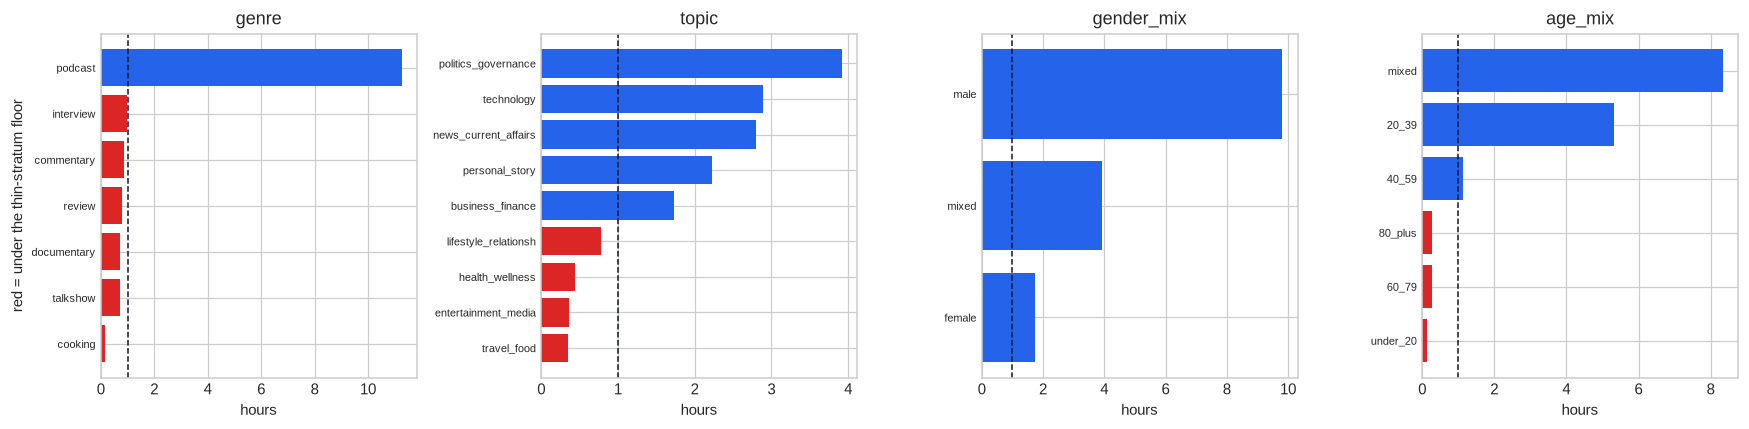

In [10]:
def stratum_table(key):
    """Hours, episodes and edit rate per level of one episode-level attribute."""
    table = (
        seg.groupby(key)
        .agg(
            hours=("hours", "sum"),
            segments=("hours", "size"),
            episodes=("episode_id", "nunique"),
            gold_hours=("hours", lambda s: seg.loc[s.index].query("pot == 'gold'")["hours"].sum()),
            mean_cmi=("cmi_ref", "mean"),
            edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
        )
        .sort_values("hours", ascending=False)
    )
    table["thin"] = np.where(table["hours"] < targets["min_stratum_hours"], "THIN", "")
    return table


COVERAGE_KEYS = ["genre", "topic", "gender_mix", "age_mix"]
for key in COVERAGE_KEYS:
    print(f"--- {key} " + "-" * (60 - len(key)))
    display(stratum_table(key))

thin = {
    key: stratum_table(key).query("thin == 'THIN'").index.tolist() for key in COVERAGE_KEYS
}
print(f"Strata under the {targets['min_stratum_hours']} h floor:")
for key, levels in thin.items():
    print(f"  {key:12s} {len(levels):2d}  {levels}")

fig, axes = plt.subplots(1, len(COVERAGE_KEYS), figsize=(4 * len(COVERAGE_KEYS), 4))
for ax, key in zip(axes, COVERAGE_KEYS):
    table = stratum_table(key).sort_values("hours")
    colors = ["#dc2626" if t == "THIN" else "#2563eb" for t in table["thin"]]
    ax.barh(range(len(table)), table["hours"], color=colors)
    ax.axvline(targets["min_stratum_hours"], color="#111827", ls="--", lw=1)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels([str(i)[:20] for i in table.index], fontsize=7.5)
    ax.set(title=key, xlabel="hours")
axes[0].set_ylabel("red = under the thin-stratum floor")
save_fig(fig, "04_stratum_coverage")
plt.show()

## 8. Multi-ASR benchmark against the human reference

Three systems transcribed every clip. The human label is the reference, so this is a real WER — on
2,300 train and 1,000 gold segments — rather than a proxy.

Two normalizations are reported, because the gap between them is itself informative:

- **raw** — the strings as written, punctuation and all.
- **normalized** — NFKC, punctuation stripped (including the Nepali danda `।`), Latin lowercased,
  Devanagari untouched. This is the fair comparison; the raw figure mostly measures who punctuates.

`Levenshtein` runs on token lists for WER and on characters for CER. Both, for three systems and
three cross-system pairs, over every segment, are computed in one parallel map.

**Read 8a before quoting any number from here.** The labels were seeded by one of the three
systems, which makes the naive per-system WER unusable as a comparison.

In [11]:
hyp_text = hyp.pivot_table(
    index="segment_id", columns="system_id", values="text", aggfunc="first"
).reindex(seg.index).fillna("")

PAIRS = [(a, b) for i, a in enumerate(SYSTEMS) for b in SYSTEMS[i + 1:]]


def score_block(items):
    """WER/CER of every system against the reference, plus pairwise cross-system distance."""
    out = []
    for segment_id, ref_raw, hyps in items:
        ref_norm = normalize_for_eval(ref_raw)
        ref_words = ref_norm.split()
        row = {
            "segment_id": segment_id,
            "ref_words": len(ref_words),
            "ref_chars": len(ref_norm),
        }
        normalized = {}
        for system, hyp_raw in hyps.items():
            hyp_norm = normalize_for_eval(hyp_raw)
            normalized[system] = hyp_norm
            hyp_words = hyp_norm.split()
            row[f"{system}|werr"] = Levenshtein.distance(ref_words, hyp_words)
            row[f"{system}|cerr"] = Levenshtein.distance(ref_norm, hyp_norm)
            row[f"{system}|werr_raw"] = Levenshtein.distance(
                (ref_raw or "").split(), (hyp_raw or "").split()
            )
            row[f"{system}|cerr_raw"] = Levenshtein.distance(ref_raw or "", hyp_raw or "")
            row[f"{system}|hyp_words"] = len(hyp_words)
        for left, right in PAIRS:
            a, b = normalized.get(left, "").split(), normalized.get(right, "").split()
            denominator = max(len(a), len(b))
            row[f"{left}~{right}|wdist"] = (
                Levenshtein.distance(a, b) / denominator if denominator else 0.0
            )
        out.append(row)
    return out


scorable = seg[seg["text"].str.len() > 0]
items = [
    (
        segment_id,
        scorable.at[segment_id, "text"],
        {s: (hyp_text.at[segment_id, s] if s in hyp_text.columns else "") or "" for s in SYSTEMS},
    )
    for segment_id in scorable.index
]

t0 = time.perf_counter()
scored = POOL(delayed(score_block)(block) for block in blocks(items, N_JOBS * 2))
parallel_seconds = time.perf_counter() - t0
t0 = time.perf_counter()
score_block(items)
serial_seconds = time.perf_counter() - t0
timed(
    "levenshtein",
    parallel_seconds,
    f"{len(items):,} segments x ({len(SYSTEMS)} systems + {len(PAIRS)} pairs), word and "
    f"character level; serial {serial_seconds:.2f}s ({serial_seconds / parallel_seconds:.1f}x)",
)

ev = pd.DataFrame([row for part in scored for row in part]).set_index("segment_id")
ev = ev.join(
    seg[["pot", "split", "disposition", "is_edited", "verification_tier", "seed_system_id",
         "cmi_ref", "latin_share_pct", "n_dev", "n_latin", "duration_seconds",
         "word_disagreement_rate", "cer_between_hypotheses", "episode_id", "genre"]]
)
print(f"scored {len(ev):,} segments; {len(seg) - len(ev)} skipped for an empty reference")

  [levenshtein] 0.06s — 4,785 segments x (3 systems + 3 pairs), word and character level; serial 0.30s (4.8x)
scored 4,785 segments; 12 skipped for an empty reference


### 8a. The benchmark is contaminated by seeding — read both tables

Every segment reached the annotator pre-filled with **one** system's hypothesis. When the annotator
accepts unchanged, the label *is* that system's output, so its WER on those segments is zero by
construction. It is not a measurement. Scribe seeded roughly two thirds of the corpus, so the
naive table below flatters it heavily.

The honest comparison is **seed-excluded**: score each system only on the segments some *other*
system seeded. It is the same statistic, computed where the label was not written by the system
being scored. Both tables are printed; every headline number elsewhere in this notebook uses the
seed-excluded one.

The interval around each number is bootstrapped **two** ways. Resampling segments assumes every
clip is an independent draw; they are not, because segments from one recording share a speaker, a
microphone and a room. Resampling whole episodes is the honest test of a claim about *systems*,
and it is the one every conclusion here rests on.

In [12]:
def corpus_rates(frame, system):
    """Corpus-level (micro-averaged) WER and CER — total errors over total reference length."""
    if frame.empty or frame["ref_words"].sum() == 0:
        return {k: float("nan") for k in ("WER %", "CER %", "WER raw %", "CER raw %")}
    return {
        "WER %": 100 * frame[f"{system}|werr"].sum() / frame["ref_words"].sum(),
        "CER %": 100 * frame[f"{system}|cerr"].sum() / frame["ref_chars"].sum(),
        "WER raw %": 100 * frame[f"{system}|werr_raw"].sum() / frame["ref_words"].sum(),
        "CER raw %": 100 * frame[f"{system}|cerr_raw"].sum() / frame["ref_chars"].sum(),
    }


SCOPES = [
    ("all labeled", ev),
    ("gold (test)", ev[ev["pot"] == "gold"]),
    ("train", ev[ev["pot"] == "train"]),
    ("verified only", ev[ev["verification_tier"] == "verified"]),
]

naive_rows, excluded_rows = [], []
for scope, frame in SCOPES:
    if frame.empty:
        continue
    for system in SYSTEMS:
        naive_rows.append({"scope": scope, "system": system, "n": len(frame),
                           **corpus_rates(frame, system)})
        unseeded = frame[frame["seed_system_id"] != system]
        excluded_rows.append({"scope": scope, "system": system, "n": len(unseeded),
                              **corpus_rates(unseeded, system)})

bench_naive = pd.DataFrame(naive_rows).set_index(["scope", "system"])
bench = pd.DataFrame(excluded_rows).set_index(["scope", "system"])

print("AS LABELED — every system scored on every segment, including the ones it seeded.")
print("Not a fair comparison; kept only to show the size of the distortion.")
display(bench_naive)
print()
print("SEED-EXCLUDED — each system scored only where another system pre-filled the label.")
display(bench)

distortion = (bench["WER %"] - bench_naive["WER %"]).unstack()
print("WER points that seeding hides — how much lower the naive number is than the honest one:")
display(distortion)

AS LABELED — every system scored on every segment, including the ones it seeded.
Not a fair comparison; kept only to show the size of the distortion.


n   WER %   CER %  WER raw %  CER raw %
scope         system                                                          
all labeled   elevenlabs-scribe-v2  4785 10.7854  5.4364    13.4353     6.3025
              gemini-3.8-flash      4785 25.2385 12.8822    31.7265    14.8824
              mai-transcribe-2      4785 24.1348 13.6867    29.2310    15.8253
gold (test)   elevenlabs-scribe-v2   927 17.8265  8.1133    22.3028     9.4317
              gemini-3.8-flash       927 23.0909 10.1516    28.2843    11.7215
              mai-transcribe-2       927 23.6386 13.6113    27.2914    15.0845
train         elevenlabs-scribe-v2  3858  9.3542  4.8719    11.6329     5.6427
              gemini-3.8-flash      3858 25.6750 13.4581    32.4261    15.5489
              mai-transcribe-2      3858 24.2357 13.7026    29.6252    15.9815
verified only elevenlabs-scribe-v2  3578 12.8363  6.4431    15.9713     7.4918
              gemini-3.8-flash      3578 25.8430 13.4211    32.0872    15.4411
              mai-transcribe-2      3578 24.8101 13.9215    29.9762    16.1449


SEED-EXCLUDED — each system scored only where another system pre-filled the label.


n   WER %   CER %  WER raw %  CER raw %
scope         system                                                          
all labeled   elevenlabs-scribe-v2  1768 22.9409 10.6028    29.8643    12.8056
              gemini-3.8-flash      4133 28.6035 14.2662    36.1511    16.5661
              mai-transcribe-2      3669 30.1154 16.9032    36.6602    19.6424
gold (test)   elevenlabs-scribe-v2   657 24.2917 10.7572    30.8234    12.6683
              gemini-3.8-flash       706 29.4140 12.3501    36.3239    14.3767
              mai-transcribe-2       491 35.8171 19.8515    41.9174    22.2528
train         elevenlabs-scribe-v2  1111 22.3457 10.5321    29.4417    12.8685
              gemini-3.8-flash      3427 28.4636 14.6117    36.1213    16.9608
              mai-transcribe-2      3178 29.2932 16.4649    35.9020    19.2543
verified only elevenlabs-scribe-v2  1543 23.8665 11.0972    30.8412    13.3577
              gemini-3.8-flash      2931 30.6959 15.4915    38.3632    17.9379
              mai-transcribe-2      2682 31.3231 17.3274    38.0881    20.2298

WER points that seeding hides — how much lower the naive number is than the honest one:


system,elevenlabs-scribe-v2,gemini-3.8-flash,mai-transcribe-2
scope,,,
all labeled,12.1555,3.3650,5.9806
gold (test),6.4653,6.3231,12.1785
train,12.9915,2.7886,5.0575
verified only,11.0302,4.8529,6.5130


In [13]:
SHORT = {s: s.split("-")[0] for s in SYSTEMS}


def bootstrap_wer(seed, errors, lengths, n_resamples):
    """Segment-level bootstrap of a micro-averaged rate; returns one array of resampled rates."""
    rng = np.random.default_rng(seed)
    n = len(errors)
    out = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, n)
        out[i] = errors[idx].sum() / lengths[idx].sum()
    return out


def bootstrap_wer_clustered(seed, episode_errors, episode_lengths, n_resamples):
    """Episode-level (cluster) bootstrap: resample whole recordings rather than segments.

    Segments inside one episode share a speaker, a microphone and a room, so they are not
    independent draws and a segment-level interval understates the uncertainty of a claim about
    *systems*. A micro-averaged WER is a ratio of sums, so resampling recordings only needs each
    episode's error and reference-length totals.
    """
    rng = np.random.default_rng(seed)
    n = len(episode_errors)
    out = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, n)
        out[i] = episode_errors[idx].sum() / episode_lengths[idx].sum()
    return out


N_BOOT = 4000
per_seed = max(1, N_BOOT // N_JOBS)
gold = ev[ev["pot"] == "gold"]
gold_unseeded = {s: gold[gold["seed_system_id"] != s] for s in SYSTEMS}
episode_totals = {
    s: gold_unseeded[s].groupby("episode_id")[[f"{s}|werr", "ref_words"]].sum() for s in SYSTEMS
}

t0 = time.perf_counter()
boot_parts = POOL(
    delayed(bootstrap_wer)(
        1000 + seed,
        gold_unseeded[system][f"{system}|werr"].to_numpy(),
        gold_unseeded[system]["ref_words"].to_numpy(),
        per_seed,
    )
    for system in SYSTEMS
    for seed in range(N_JOBS)
)
cluster_parts = POOL(
    delayed(bootstrap_wer_clustered)(
        2000 + seed,
        episode_totals[system][f"{system}|werr"].to_numpy(),
        episode_totals[system]["ref_words"].to_numpy(),
        per_seed,
    )
    for system in SYSTEMS
    for seed in range(N_JOBS)
)
timed("bootstrap", time.perf_counter() - t0,
      f"{len(SYSTEMS)} systems x {per_seed * N_JOBS:,} segment-level and {per_seed * N_JOBS:,} "
      "episode-clustered resamples of the seed-excluded gold pool")

ci_rows = []
for index, system in enumerate(SYSTEMS):
    window = slice(index * N_JOBS, (index + 1) * N_JOBS)
    frame = gold_unseeded[system]
    point = 100 * frame[f"{system}|werr"].sum() / frame["ref_words"].sum()
    seg_lo, seg_hi = np.percentile(np.concatenate(boot_parts[window]) * 100, [2.5, 97.5])
    ep_lo, ep_hi = np.percentile(np.concatenate(cluster_parts[window]) * 100, [2.5, 97.5])
    ci_rows.append({"system": system, "n": len(frame),
                    "episodes": frame["episode_id"].nunique(), "gold WER %": point,
                    "seg CI low": seg_lo, "seg CI high": seg_hi, "seg +/-": (seg_hi - seg_lo) / 2,
                    "episode CI low": ep_lo, "episode CI high": ep_hi,
                    "episode +/-": (ep_hi - ep_lo) / 2})
ci = pd.DataFrame(ci_rows).set_index("system")
print("Gold WER, seed-excluded. Two intervals over the same numbers — the segment-level one")
print("treats every clip as an independent draw, the episode-clustered one does not:")
display(ci)

leader = ci["gold WER %"].idxmin()
runner_up = ci["gold WER %"].drop(leader).idxmin()
separated_segment = ci.loc[leader, "seg CI high"] < ci.loc[runner_up, "seg CI low"]
separated = ci.loc[leader, "episode CI high"] < ci.loc[runner_up, "episode CI low"]
n_gold_episodes = gold["episode_id"].nunique()

print(f"Best on gold: {leader}, runner-up {runner_up}.")
print(f"  segment-level interval : {'separated' if separated_segment else 'overlapping'}")
print(f"  episode-clustered      : {'separated' if separated else 'OVERLAPPING'}"
      f"  <- the one to quote")
print(f"So the ordering is {'resolved' if separated else 'NOT resolved'} at this corpus size: "
      f"gold holds {n_gold_episodes} recordings,")
print(f"not {len(gold):,} independent draws, and the interval that matters is the one over "
      "recordings.")
if n_gold_episodes < 10:
    print(f"  WARNING: {n_gold_episodes} gold episodes is too few for a cluster bootstrap to be "
          "stable. Widening")
    print("  gold means more distinct recordings, not more hours of the ones already in it.")

print()
print("Per-episode gold WER, seed-excluded — the between-recording spread the cluster")
print("interval is reading, and the segment-level one is blind to:")
per_episode_rows = []
for episode, frame in gold.groupby("episode_id"):
    row = {"episode": episode[:38], "segments": len(frame),
           "mean CMI": frame["cmi_ref"].mean(),
           "latin %": frame["latin_share_pct"].fillna(0).mean()}
    for system in SYSTEMS:
        unseeded = frame[frame["seed_system_id"] != system]
        row[f"{SHORT[system]} WER %"] = (
            corpus_rates(unseeded, system)["WER %"] if len(unseeded) else np.nan
        )
    per_episode_rows.append(row)
display(pd.DataFrame(per_episode_rows).set_index("episode"))

print()
print("Cross-system distance (normalized word level, all labeled segments) — this is the")
print("disagreement signal the queue is scored on, measured directly:")
display(ev[[f"{a}~{b}|wdist" for a, b in PAIRS]].describe().T[["mean", "50%", "std", "max"]])


  [bootstrap] 0.04s — 3 systems x 4,000 segment-level and 4,000 episode-clustered resamples of the seed-excluded gold pool
Gold WER, seed-excluded. Two intervals over the same numbers — the segment-level one
treats every clip as an independent draw, the episode-clustered one does not:


,n,episodes,gold WER %,seg CI low,seg CI high,seg +/-,episode CI low,episode CI high,episode +/-
system,,,,,,,,,
elevenlabs-scribe-v2,657,5,24.2917,22.9331,25.6839,1.3754,14.5494,31.7157,8.5831
gemini-3.8-flash,706,5,29.4140,27.9559,30.8338,1.4389,22.0981,36.6892,7.2955
mai-transcribe-2,491,5,35.8171,32.9973,38.8364,2.9196,24.5423,61.7318,18.5947


Best on gold: elevenlabs-scribe-v2, runner-up gemini-3.8-flash.
  segment-level interval : separated
  episode-clustered      : OVERLAPPING  <- the one to quote
So the ordering is NOT resolved at this corpus size: gold holds 5 recordings,
not 927 independent draws, and the interval that matters is the one over recordings.
  gold means more distinct recordings, not more hours of the ones already in it.

Per-episode gold WER, seed-excluded — the between-recording spread the cluster
interval is reading, and the segment-level one is blind to:


,segments,mean CMI,latin %,elevenlabs WER %,gemini WER %,mai WER %
episode,,,,,,
best_burger_in_ktm,50,32.2279,45.1905,17.8268,39.3604,39.8261
mailo_bajeko_kalo_maya_herne_katha_ep1,299,3.9051,3.9051,36.9439,39.7968,42.5737
minister_mahabir_pun_unfiltered_with_b,281,1.8024,1.8024,20.8511,25.4655,26.6332
pixel_11_pro_vs_galaxy_s26_ultra_i_was,34,0.0452,99.9548,1.8427,4.6916,85.6781
हमलयन_जभक_२६_वरष_सघरष_र_सफलतक_कथ,263,25.4352,25.8976,24.6702,27.0943,22.8135



Cross-system distance (normalized word level, all labeled segments) — this is the
disagreement signal the queue is scored on, measured directly:


,mean,50%,std,max
elevenlabs-scribe-v2~gemini-3.8-flash|wdist,0.3039,0.2833,0.1837,1.0000
elevenlabs-scribe-v2~mai-transcribe-2|wdist,0.3164,0.2500,0.2481,1.0000
gemini-3.8-flash~mai-transcribe-2|wdist,0.3476,0.2857,0.2437,1.0000


### 8b. Where the errors are: WER by language mix

If WER is flat across the tiers, the corpus is not buying anything a monolingual Nepali set would
not. If it climbs, the code-switched segments are the ones carrying the signal — and they are the
ones worth spending annotation time on. Seed-excluded throughout, for the reason above.

The bottom bucket is **split in two**. CMI scores a monolingual segment 0 whichever language it is
monolingual in, so `CMI ≈ 0` silently pools pure Nepali with pure English. Those two populations
have opposite error profiles, and averaging a WER over their union describes neither.

,segments,hours,latin %,edit_rate %,elevenlabs WER %,gemini WER %,mai WER %,min n
cmi_tier,,,,,,,,
monolingual Nepali,873,2.0049,0.4439,10.4238,27.3416,29.8405,28.8442,476
monolingual English,355,0.8738,99.8570,6.4789,5.5026,13.8048,83.4987,58
light (5-15),680,2.1810,19.1144,22.9412,22.6428,28.3754,30.1240,204
moderate (15-35),1836,6.4953,30.8378,20.8061,23.0263,29.6680,25.6022,597
dense (>35),1041,3.9203,46.5658,19.6926,22.4780,29.7101,24.2355,410


  figure -> notebooks/figures/eda_05_asr_benchmark.png


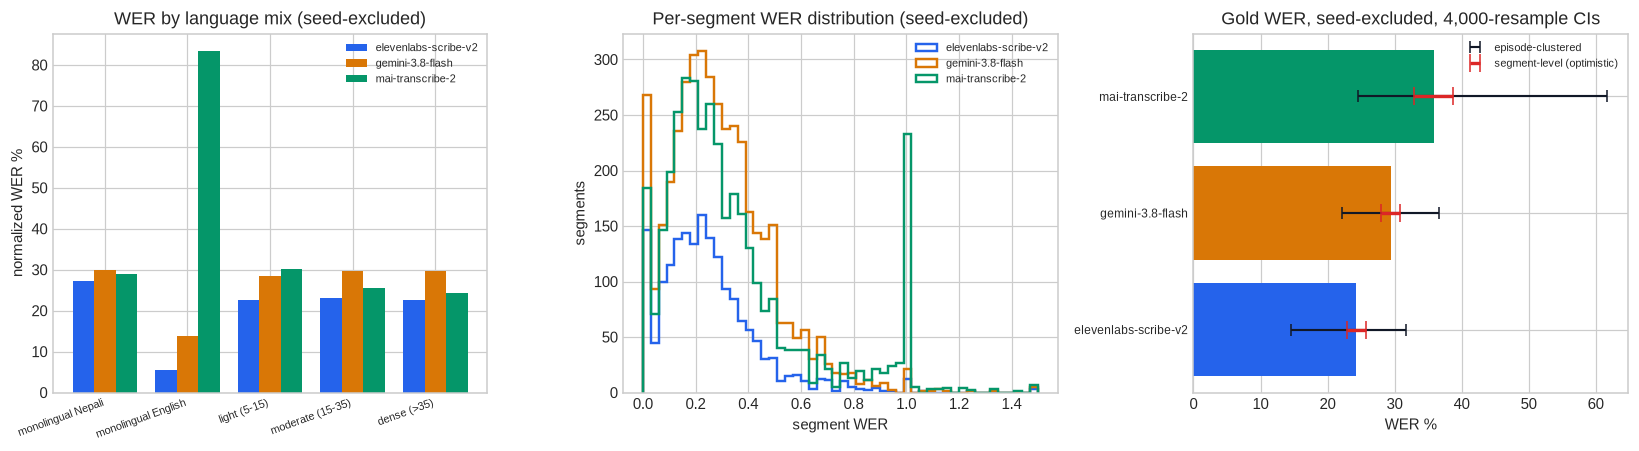

In [14]:
# CMI cannot tell a monolingual Nepali clip from a monolingual English one: both score 0, because
# the formula only sees how *balanced* the mix is. They are opposite populations with opposite
# error profiles, so the bottom bucket is split by which language it is monolingual in before any
# WER is averaged over it.
MONO_CMI = 5
ENGLISH_SHARE = 50

tier = pd.cut(
    ev["cmi_ref"],
    bins=[-0.01, MONO_CMI, 15, 35, 100],
    labels=["mono", "light (5-15)", "moderate (15-35)", "dense (>35)"],
).astype(object)
latin_share = ev["latin_share_pct"].fillna(0)
tier[(tier == "mono") & (latin_share >= ENGLISH_SHARE)] = "monolingual English"
tier[tier == "mono"] = "monolingual Nepali"
TIER_ORDER = ["monolingual Nepali", "monolingual English", "light (5-15)",
              "moderate (15-35)", "dense (>35)"]
ev["cmi_tier"] = pd.Categorical(tier, categories=TIER_ORDER, ordered=True)

tier_rows = []
for tier_name, frame in ev.groupby("cmi_tier", observed=True):
    row = {"cmi_tier": tier_name, "segments": len(frame),
           "hours": frame["duration_seconds"].sum() / 3600,
           "latin %": frame["latin_share_pct"].fillna(0).mean(),
           "edit_rate %": 100 * frame["is_edited"].mean()}
    smallest = len(frame)
    for system in SYSTEMS:
        unseeded = frame[frame["seed_system_id"] != system]
        smallest = min(smallest, len(unseeded))
        row[f"{SHORT[system]} WER %"] = corpus_rates(unseeded, system)["WER %"]
    # The seed-excluded pools differ per system; the smallest is what a tier's numbers rest on.
    row["min n"] = smallest
    tier_rows.append(row)
tier_table = pd.DataFrame(tier_rows).set_index("cmi_tier")
display(tier_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

x = np.arange(len(tier_table))
width = 0.26
for i, system in enumerate(SYSTEMS):
    axes[0].bar(x + (i - 1) * width, tier_table[f"{SHORT[system]} WER %"], width,
                label=system, color=SYS_COLOR[system])
axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_table.index, fontsize=7, rotation=20, ha="right")
axes[0].set(title="WER by language mix (seed-excluded)", ylabel="normalized WER %")
axes[0].legend(fontsize=7)

for system in SYSTEMS:
    unseeded = ev[ev["seed_system_id"] != system]
    rate = (unseeded[f"{system}|werr"] / unseeded["ref_words"].replace(0, np.nan)).clip(0, 1.5)
    axes[1].hist(rate.dropna(), bins=50, histtype="step", lw=1.6, label=system,
                 color=SYS_COLOR[system])
axes[1].set(title="Per-segment WER distribution (seed-excluded)", xlabel="segment WER",
            ylabel="segments")
axes[1].legend(fontsize=7)

# Both intervals are drawn: the wide one is the claim that survives review.
ci_sorted = ci.sort_values("gold WER %")
y = np.arange(len(ci_sorted))
episode_err = np.vstack([ci_sorted["gold WER %"] - ci_sorted["episode CI low"],
                         ci_sorted["episode CI high"] - ci_sorted["gold WER %"]])
axes[2].barh(y, ci_sorted["gold WER %"], color=[SYS_COLOR[s] for s in ci_sorted.index])
axes[2].errorbar(ci_sorted["gold WER %"], y, xerr=episode_err, fmt="none",
                 ecolor="#111827", capsize=4, lw=1.4, label="episode-clustered")
axes[2].errorbar(ci_sorted["gold WER %"], y, xerr=ci_sorted["seg +/-"].to_numpy(), fmt="none",
                 ecolor="#dc2626", capsize=6, lw=2.2, label="segment-level (optimistic)")
axes[2].set_yticks(y)
axes[2].set_yticklabels(ci_sorted.index, fontsize=8)
axes[2].set(title=f"Gold WER, seed-excluded, {N_BOOT:,}-resample CIs", xlabel="WER %")
axes[2].legend(fontsize=7)

save_fig(fig, "05_asr_benchmark")
plt.show()


### 8c. Is it recognition error, or is it the wrong script?

A system that hears English correctly but writes it in Devanagari (`So throughout 2026` →
`सो थ्रूआउट 2026`) scores a near-total WER on that segment while having understood every word.
That is an orthography difference, not a recognition failure, and it is exactly the behaviour
`app/llm/script_restore.py` was kept for (D51).

So before any system ordering is quoted, the corpus is scored again with the English-dominant
references removed. If a system's WER moves by more than a point or two, its headline number is
partly a measurement of its spelling convention.

In [15]:
ENGLISH_DOMINANT = 90  # % of a reference's language tokens that are Latin script

english_dominant = ev[ev["latin_share_pct"].fillna(0) >= ENGLISH_DOMINANT]
print(f"References that are >={ENGLISH_DOMINANT}% Latin: {len(english_dominant):,} segments "
      f"({100 * len(english_dominant) / len(ev):.1f}% of the corpus) "
      f"across {english_dominant['episode_id'].nunique()} episodes.")
print()


def devanagari_share(text):
    """Share of a hypothesis's own non-numeric tokens written in Devanagari."""
    tokens = [t for t in TOK_RE.findall(unicodedata.normalize("NFKC", text or ""))
              if not t.isdigit()]
    return sum(1 for t in tokens if DEV_RE.search(t)) / len(tokens) if tokens else np.nan


script_rows = []
for system in SYSTEMS:
    unseeded = ev[ev["seed_system_id"] != system]
    kept = unseeded[unseeded["latin_share_pct"].fillna(0) < ENGLISH_DOMINANT]
    on_english = english_dominant[english_dominant["seed_system_id"] != system]
    wer_all = corpus_rates(unseeded, system)["WER %"]
    wer_kept = corpus_rates(kept, system)["WER %"]
    own_output = (hyp_text.loc[english_dominant.index, system]
                  if system in hyp_text.columns else pd.Series(dtype=object))
    script_rows.append({
        "system": system,
        "WER % (all)": wer_all,
        "WER % (English-dominant dropped)": wer_kept,
        "delta pts": wer_all - wer_kept,
        "WER % on English-dominant": corpus_rates(on_english, system)["WER %"],
        "n there": len(on_english),
        "Devanagari % of own output there": 100 * own_output.map(devanagari_share).mean(),
    })
script_table = pd.DataFrame(script_rows).set_index("system")
print("A large positive delta means the system is being penalised for the script it chose, not")
print("for what it heard. The last column is the evidence: what it actually wrote there.")
display(script_table)

print()
print("Does the gold ordering survive dropping that material?")
gold_kept = gold[gold["latin_share_pct"].fillna(0) < ENGLISH_DOMINANT]
sensitivity = pd.DataFrame([
    {"system": system,
     "gold WER %": corpus_rates(gold[gold["seed_system_id"] != system], system)["WER %"],
     "gold WER % (dropped)": corpus_rates(
         gold_kept[gold_kept["seed_system_id"] != system], system)["WER %"]}
    for system in SYSTEMS
]).set_index("system")
sensitivity["rank"] = sensitivity["gold WER %"].rank().astype(int)
sensitivity["rank (dropped)"] = sensitivity["gold WER % (dropped)"].rank().astype(int)
display(sensitivity)

order_changes = not sensitivity["rank"].equals(sensitivity["rank (dropped)"])
dropped_episodes = gold["episode_id"].nunique() - gold_kept["episode_id"].nunique()
if order_changes:
    print("The gold ordering CHANGES when English-dominant material is dropped, so the ranking in")
    print("8a is an artifact of that material rather than a property of the systems.")
else:
    print("The gold ordering is unchanged, so it does not rest on the English-dominant material.")
print(f"Dropping it removes {len(gold) - len(gold_kept):,} of {len(gold):,} gold segments and "
      f"{dropped_episodes} whole gold episode(s).")


References that are >=90% Latin: 387 segments (8.1% of the corpus) across 14 episodes.



A large positive delta means the system is being penalised for the script it chose, not
for what it heard. The last column is the evidence: what it actually wrote there.


,WER % (all),WER % (English-dominant dropped),delta pts,WER % on English-dominant,n there,Devanagari % of own output there
system,,,,,,
elevenlabs-scribe-v2,22.9409,23.5555,-0.6147,5.8853,62,1.2433
gemini-3.8-flash,28.6035,29.6368,-1.0333,14.0577,344,3.4786
mai-transcribe-2,30.1154,25.9228,4.1926,79.9756,368,78.5445



Does the gold ordering survive dropping that material?


,gold WER %,gold WER % (dropped),rank,rank (dropped)
system,,,,
elevenlabs-scribe-v2,24.2917,26.2595,1,1
gemini-3.8-flash,29.4140,31.0061,2,3
mai-transcribe-2,35.8171,29.7045,3,2


The gold ordering CHANGES when English-dominant material is dropped, so the ranking in
8a is an artifact of that material rather than a property of the systems.
Dropping it removes 37 of 927 gold segments and 1 whole gold episode(s).


### 8d. Scoring the words instead of the spelling

Section 8c says *that* a system is being charged for its script. This section charges it properly.

`app/llm/script_restore.py` is the harness's answer to this, but it is an LLM rewrite: it costs a
call per segment and writes `llm_requests` rows, so it cannot run from a notebook and it is not
what is wanted here. Nothing below touches the database or the export. It is a **second way of
reading the same hypotheses**, computed at analysis time.

The method: align each hypothesis to the reference with the same Levenshtein edit script the WER
already uses, then look at every **substitution** where one side is Devanagari and the other is
Latin. Romanize the Devanagari, reduce both sides to a coarse consonant skeleton — Nepali writes
English `v`/`w` with `भ`, `f` with `फ`, `z` with `ज`, so those classes are merged — and if the two
are close enough, count the substitution as *the same word in the other script* rather than as a
recognition error. Everything else is scored exactly as before.

Three numbers come out of it, and all three are reported:

- **raw WER** — unchanged, and still the headline. A consumer of these transcripts receives the
  Devanagari, so the raw number is the one that describes the artifact.
- **script-folded WER** — substitutions the matcher recognises as the same word are forgiven. The
  matcher is deliberately conservative (it still rejects `the`/`द`, `of`/`ऑफ`, `they`/`दे`), so
  this **over**states the error a perfect script restoration would leave.
- **oracle floor** — every cross-script substitution forgiven, whether or not it is the same word.
  Nothing can do better than this, so the truth is between the two.

Two guards against this becoming a metric that flatters one system. First, it is applied
identically to all three: the two that do not transliterate should barely move, and the printout
below says by how much. Second, the acceptance threshold is a knob, so its whole sweep is printed
rather than one chosen value, along with a sample of what the matcher accepted and rejected.

In [16]:
FOLD_THRESHOLD = 0.5   # normalized edit distance below which two skeletons are "the same word"
MIN_SKELETON = 2       # a 1-character skeleton collides with too much to be evidence
SHORT_TOKEN = 4        # below this length, compare whole romanized strings, not skeletons
FOLD_SWEEP = (0.0, 0.25, 0.34, 0.5, 0.6)

LAT_RE_FOLD = re.compile(r"[A-Za-z]")

#: Devanagari -> ASCII, longest match first. Deliberately crude: it feeds a skeleton, not a reader.
ROMAN = {
    "क्ष": "ksh", "त्र": "tr", "ज्ञ": "gy", "श्र": "shr",
    "ख": "kh", "घ": "gh", "छ": "ch", "झ": "jh", "ठ": "th", "ढ": "dh", "थ": "th", "ध": "dh",
    "फ": "ph", "भ": "bh", "क": "k", "ग": "g", "ङ": "n", "च": "c", "ज": "j", "ञ": "n",
    "ट": "t", "ड": "d", "ण": "n", "त": "t", "द": "d", "न": "n", "प": "p", "ब": "b",
    "म": "m", "य": "y", "र": "r", "ल": "l", "व": "v", "श": "sh", "ष": "sh", "स": "s",
    "ह": "h", "ळ": "l", "ऱ": "r", "क़": "k", "ख़": "kh", "ग़": "g", "ज़": "z", "ड़": "d",
    "ढ़": "dh", "फ़": "f", "य़": "y",
    "अ": "a", "आ": "a", "इ": "i", "ई": "i", "उ": "u", "ऊ": "u", "ऋ": "ri", "ए": "e",
    "ऐ": "ai", "ओ": "o", "औ": "au", "ऑ": "o", "ऍ": "e",
    "ा": "a", "ि": "i", "ी": "i", "ु": "u", "ू": "u", "ृ": "ri", "े": "e", "ै": "ai",
    "ो": "o", "ौ": "au", "ॉ": "o", "ॅ": "e", "ॆ": "e", "ॊ": "o",
    "्": "", "ं": "n", "ँ": "n", "ः": "h", "ऽ": "", "़": "",
}
_ROMAN_RE = re.compile("|".join(re.escape(k) for k in sorted(ROMAN, key=len, reverse=True)))

# Nepali has no /v/-/w/ contrast and renders English f, z, th with भ/फ, ज, थ — so those collapse.
CONSONANT_CLASS = str.maketrans({
    "w": "b", "v": "b", "b": "b", "f": "p", "p": "p", "z": "j", "j": "j",
    "q": "k", "k": "k", "x": "k", "c": "k", "g": "k", "d": "t", "t": "t",
    "s": "s", "n": "n", "m": "n", "r": "r", "l": "r", "y": "y", "h": "h",
})
DIGRAPHS = (("ph", "p"), ("bh", "b"), ("kh", "k"), ("gh", "k"),
            ("th", "t"), ("dh", "t"), ("ch", "k"), ("sh", "s"))
VOWELS = str.maketrans("", "", "aeiou")


def romanize(token):
    """Devanagari to ASCII. Latin tokens pass through unchanged."""
    return _ROMAN_RE.sub(lambda m: ROMAN[m.group(0)], unicodedata.normalize("NFC", token))


def ascii_form(token):
    return re.sub(r"[^a-z]", "", romanize(token).lower())


def skeleton(token):
    """Coarse consonant skeleton: romanize, fold digraphs, drop vowels, merge confusable classes."""
    text = ascii_form(token)
    for digraph, single in DIGRAPHS:
        text = text.replace(digraph, single)
    text = text.translate(VOWELS).translate(CONSONANT_CLASS)
    return re.sub(r"(.)\1+", r"\1", text)


def cross_script(a, b):
    """One side Devanagari, the other Latin — the only pairs this section reconsiders."""
    return (bool(DEV_RE.search(a)) != bool(DEV_RE.search(b))) and bool(
        LAT_RE_FOLD.search(a) or LAT_RE_FOLD.search(b)
    )


def same_word_across_scripts(a, b, threshold):
    """Is this cross-script substitution plausibly one word spelled two ways?"""
    left, right = ascii_form(a), ascii_form(b)
    if not left or not right:
        return False
    ka, kb = skeleton(a), skeleton(b)
    if min(len(ka), len(kb)) >= MIN_SKELETON and Levenshtein.normalized_distance(ka, kb) <= threshold:
        return True
    if Levenshtein.normalized_distance(left, right) <= threshold:
        return True
    # "i"/"आई", "a"/"अ": too short for a ratio to mean anything.
    return max(len(left), len(right)) <= SHORT_TOKEN and Levenshtein.distance(left, right) <= 1


def fold_block(items):
    """Per segment and system: raw errors, errors after folding, and the oracle floor."""
    out = []
    for segment_id, ref, hyps in items:
        row = {"segment_id": segment_id}
        for system, hyp in hyps.items():
            ops = Levenshtein.editops(ref, hyp)
            raw = len(ops)
            candidates = [(ref[op.src_pos], hyp[op.dest_pos]) for op in ops
                          if op.tag == "replace" and cross_script(ref[op.src_pos], hyp[op.dest_pos])]
            row[f"{system}|oracle"] = raw - len(candidates)
            for threshold in FOLD_SWEEP:
                forgiven = sum(1 for a, b in candidates
                               if same_word_across_scripts(a, b, threshold))
                row[f"{system}|fold@{threshold}"] = raw - forgiven
        out.append(row)
    return out


fold_items = [
    (segment_id,
     normalize_for_eval(seg.at[segment_id, "text"]).split(),
     {s: normalize_for_eval(hyp_text.at[segment_id, s] if s in hyp_text.columns else "").split()
      for s in SYSTEMS})
    for segment_id in ev.index
]
t0 = time.perf_counter()
fold_parts = POOL(delayed(fold_block)(block) for block in blocks(fold_items, N_JOBS * 2))
timed("script fold", time.perf_counter() - t0,
      f"{len(fold_items):,} segments x {len(SYSTEMS)} systems x {len(FOLD_SWEEP)} thresholds")
fold = pd.DataFrame([row for part in fold_parts for row in part]).set_index("segment_id")
ev = ev.join(fold)


def fold_rates(frame, system):
    """Raw, folded and oracle WER for one system over one slice."""
    words = frame["ref_words"].sum()
    if not words:
        return {k: float("nan") for k in ("raw WER %", "script-folded %", "oracle floor %")}
    return {
        "raw WER %": 100 * frame[f"{system}|werr"].sum() / words,
        "script-folded %": 100 * frame[f"{system}|fold@{FOLD_THRESHOLD}"].sum() / words,
        "oracle floor %": 100 * frame[f"{system}|oracle"].sum() / words,
    }


english_only = ev["latin_share_pct"].fillna(0) >= ENGLISH_DOMINANT
FOLD_SCOPES = [
    ("all labeled", ev),
    ("gold (test)", ev[ev["pot"] == "gold"]),
    ("English-dominant refs", ev[english_only]),
    ("everything else", ev[~english_only]),
]
for scope, frame in FOLD_SCOPES:
    table = pd.DataFrame([
        {"system": system, **fold_rates(frame[frame["seed_system_id"] != system], system),
         "n": len(frame[frame["seed_system_id"] != system])}
        for system in SYSTEMS
    ]).set_index("system")
    table["fold moves it"] = table["raw WER %"] - table["script-folded %"]
    table["raw rank"] = table["raw WER %"].rank().astype(int)
    table["folded rank"] = table["script-folded %"].rank().astype(int)
    print(f"--- {scope} (seed-excluded, threshold {FOLD_THRESHOLD}) "
          + "-" * max(0, 44 - len(scope)))
    display(table)

control = {system: 0.0 for system in SYSTEMS}
for system in SYSTEMS:
    unseeded = ev[ev["seed_system_id"] != system]
    control[system] = (100 * (unseeded[f"{system}|werr"].sum()
                              - unseeded[f"{system}|fold@{FOLD_THRESHOLD}"].sum())
                       / unseeded["ref_words"].sum())
transliterator = max(control, key=control.get)
others = [s for s in SYSTEMS if s != transliterator]
print(f"CONTROL: the fold moves {transliterator} by {control[transliterator]:.2f} WER points and "
      f"the others by "
      + ", ".join(f"{control[s]:.2f}" for s in others) + ".")
print("A general WER discount would move all three by the same amount; this does not, which is")
print("what separates a script correction from a thumb on the scale.")

print()
print(f"THRESHOLD SWEEP — corpus-wide folded WER at every setting, so nothing rests on {FOLD_THRESHOLD}:")
sweep_rows = []
for threshold in FOLD_SWEEP:
    row = {"threshold": threshold}
    for system in SYSTEMS:
        unseeded = ev[ev["seed_system_id"] != system]
        row[SHORT[system]] = (100 * unseeded[f"{system}|fold@{threshold}"].sum()
                              / unseeded["ref_words"].sum())
    sweep_rows.append(row)
display(pd.DataFrame(sweep_rows).set_index("threshold"))
print("0.0 forgives only near-exact skeleton matches; the oracle floor is the limit of the sweep.")

print()
print(f"WHAT THE MATCHER DID on {transliterator}, English-dominant references only:")
accepted, rejected = Counter(), Counter()
for segment_id in ev[english_only & (ev["seed_system_id"] != transliterator)].index:
    ref_tokens = normalize_for_eval(seg.at[segment_id, "text"]).split()
    hyp_tokens = normalize_for_eval(hyp_text.at[segment_id, transliterator]).split()
    for op in Levenshtein.editops(ref_tokens, hyp_tokens):
        if op.tag != "replace":
            continue
        a, b = ref_tokens[op.src_pos], hyp_tokens[op.dest_pos]
        if not cross_script(a, b):
            continue
        target = accepted if same_word_across_scripts(a, b, FOLD_THRESHOLD) else rejected
        target[(a, b)] += 1
print(f"  accepted {sum(accepted.values()):,} cross-script substitutions, "
      f"rejected {sum(rejected.values()):,}")
print("  accepted: " + "; ".join(f"{a}|{b}" for (a, b), _ in accepted.most_common(18)))
print("  rejected: " + "; ".join(f"{a}|{b}" for (a, b), _ in rejected.most_common(12)))
print("  Every rejected pair above is also a real match, so the fold under-forgives and the")
print("  script-folded column is an upper bound on what a perfect restoration would leave.")


  [script fold] 0.17s — 4,785 segments x 3 systems x 5 thresholds
--- all labeled (seed-excluded, threshold 0.5) ---------------------------------


,raw WER %,script-folded %,oracle floor %,n,fold moves it,raw rank,folded rank
system,,,,,,,
elevenlabs-scribe-v2,22.9409,21.6738,20.7384,1768,1.2671,1,1
gemini-3.8-flash,28.6035,25.9890,24.3329,4133,2.6144,2,3
mai-transcribe-2,30.1154,24.6887,20.5296,3669,5.4267,3,2


--- gold (test) (seed-excluded, threshold 0.5) ---------------------------------


,raw WER %,script-folded %,oracle floor %,n,fold moves it,raw rank,folded rank
system,,,,,,,
elevenlabs-scribe-v2,24.2917,22.7742,22.1741,657,1.5175,1,1
gemini-3.8-flash,29.4140,27.8476,27.0911,706,1.5663,2,2
mai-transcribe-2,35.8171,28.3316,23.8690,491,7.4855,3,3


--- English-dominant refs (seed-excluded, threshold 0.5) -----------------------


...

--- everything else (seed-excluded, threshold 0.5) -----------------------------


,raw WER %,script-folded %,oracle floor %,n,fold moves it,raw rank,folded rank
system,,,,,,,
elevenlabs-scribe-v2,23.5555,22.2629,21.2974,1706,1.2927,1,1
gemini-3.8-flash,29.6368,26.8988,25.2257,3789,2.7380,3,3
mai-transcribe-2,25.9228,23.1593,21.6405,3301,2.7635,2,2


CONTROL: the fold moves mai-transcribe-2 by 5.43 WER points and the others by 1.27, 2.61.
A general WER discount would move all three by the same amount; this does not, which is
what separates a script correction from a thumb on the scale.

THRESHOLD SWEEP — corpus-wide folded WER at every setting, so nothing rests on 0.5:


,elevenlabs,gemini,mai
threshold,,,
0.0000,22.3638,27.1543,26.6710
0.2500,22.0903,26.7262,25.9495
0.3400,21.8838,26.3576,25.3586
0.5000,21.6738,25.9890,24.6887
0.6000,21.6208,25.8957,24.5399


0.0 forgives only near-exact skeleton matches; the oracle floor is the limit of the sweep.

WHAT THE MATCHER DID on mai-transcribe-2, English-dominant references only:
  accepted 3,346 cross-script substitutions, rejected 3,207
  accepted: i|आई; you|यू; and|एंड; to|टू; so|सो; is|इज; a|अ; it|इट; in|इन; but|बट; know|नो; are|आर; me|मी; like|लाइक; think|थिंक; for|फॉर; yeah|या; what|व्हाट
  rejected: the|द; uh|अ; that|दैट; of|ऑफ; the|दी; um|अँ; if|इफ; uh|अँ; now|नाउ; they|दे; one|वन; mm|हुँ
  Every rejected pair above is also a real match, so the fold under-forgives and the
  script-folded column is an upper bound on what a perfect restoration would leave.


  figure -> notebooks/figures/eda_05b_script_folding.png


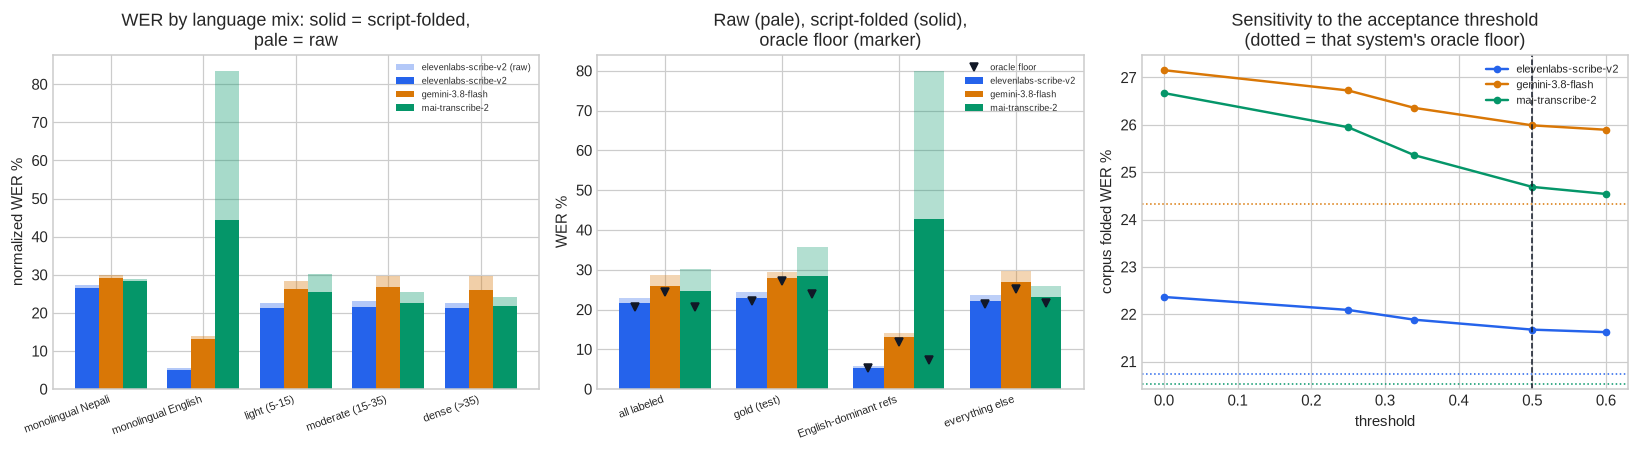

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# 1. the tier chart from 8b, re-drawn with the fold on top of the raw bars
x = np.arange(len(tier_table))
width = 0.26
for i, system in enumerate(SYSTEMS):
    raw_vals, fold_vals = [], []
    for tier_name in tier_table.index:
        frame = ev[(ev["cmi_tier"] == tier_name) & (ev["seed_system_id"] != system)]
        rates = fold_rates(frame, system)
        raw_vals.append(rates["raw WER %"])
        fold_vals.append(rates["script-folded %"])
    offset = x + (i - 1) * width
    axes[0].bar(offset, raw_vals, width, color=SYS_COLOR[system], alpha=0.35,
                label=f"{system} (raw)" if i == 0 else None)
    axes[0].bar(offset, fold_vals, width, color=SYS_COLOR[system], label=system)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_table.index, fontsize=7, rotation=20, ha="right")
axes[0].set(title="WER by language mix: solid = script-folded,\npale = raw",
            ylabel="normalized WER %")
axes[0].legend(fontsize=6)

# 2. raw -> folded -> oracle, on the material where the problem lives
scope_names = [name for name, _ in FOLD_SCOPES]
for i, system in enumerate(SYSTEMS):
    raw_vals, fold_vals, oracle_vals = [], [], []
    for _, frame in FOLD_SCOPES:
        rates = fold_rates(frame[frame["seed_system_id"] != system], system)
        raw_vals.append(rates["raw WER %"])
        fold_vals.append(rates["script-folded %"])
        oracle_vals.append(rates["oracle floor %"])
    offset = np.arange(len(scope_names)) + (i - 1) * width
    axes[1].bar(offset, raw_vals, width, color=SYS_COLOR[system], alpha=0.3)
    axes[1].bar(offset, fold_vals, width, color=SYS_COLOR[system], label=system)
    axes[1].plot(offset, oracle_vals, "v", color="#111827", markersize=5,
                 label="oracle floor" if i == 0 else None)
axes[1].set_xticks(np.arange(len(scope_names)))
axes[1].set_xticklabels(scope_names, fontsize=7, rotation=20, ha="right")
axes[1].set(title="Raw (pale), script-folded (solid),\noracle floor (marker)", ylabel="WER %")
axes[1].legend(fontsize=6)

# 3. the knob, drawn, so no single threshold is load-bearing
sweep_frame = pd.DataFrame(sweep_rows).set_index("threshold")
for system in SYSTEMS:
    axes[2].plot(sweep_frame.index, sweep_frame[SHORT[system]], "o-",
                 color=SYS_COLOR[system], label=system, lw=1.6, markersize=4)
    unseeded = ev[ev["seed_system_id"] != system]
    axes[2].axhline(100 * unseeded[f"{system}|oracle"].sum() / unseeded["ref_words"].sum(),
                    color=SYS_COLOR[system], ls=":", lw=1)
axes[2].axvline(FOLD_THRESHOLD, color="#111827", ls="--", lw=1)
axes[2].set(title="Sensitivity to the acceptance threshold\n(dotted = that system's oracle floor)",
            xlabel="threshold", ylabel="corpus folded WER %")
axes[2].legend(fontsize=7)

save_fig(fig, "05b_script_folding")
plt.show()


## 9. Does cross-ASR disagreement predict a human edit?

This is the load-bearing question for the queue. If disagreement ranks segments well, a threshold
can auto-approve the quiet tail and spend annotator time on the noisy head.

**The analysis must exclude screened rows.** A screened row was accepted *because* its disagreement
was low — scoring the signal on rows it selected would be measuring the selection rule against
itself. Everything below runs on `verified` rows only, where a human listened regardless of what
the signal said.

Two separate things are then worth reading apart:

- **Ranking quality** (AUC) — can the signal order segments by whether they need an edit?
- **The achievable ceiling** — set by the base edit rate, not by the ranking. Auto-approving a
  share *c* of the queue admits at least `c - (1 - base_edit_rate)` edited segments once *c* passes
  `1 - base_edit_rate`, no matter how good the ordering is.

In [18]:
signal_frame = ev[ev["verification_tier"] == "verified"].copy()
signal_frame["measured_disagreement"] = signal_frame[
    [f"{a}~{b}|wdist" for a, b in PAIRS]
].mean(axis=1)

CANDIDATES = {
    "word_disagreement_rate (stored)": "word_disagreement_rate",
    "cer_between_hypotheses (stored)": "cer_between_hypotheses",
    "mean pairwise word distance (measured here)": "measured_disagreement",
    "reference CMI": "cmi_ref",
    "clip duration": "duration_seconds",
}

y = signal_frame["is_edited"].to_numpy()
base_rate = y.mean()


def auc(labels, scores):
    """Mann-Whitney AUC with tie-corrected ranks; NaN scores are treated as the minimum."""
    scores = np.nan_to_num(np.asarray(scores, dtype=float), nan=np.nanmin(scores))
    ranks = st.rankdata(scores)
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    return (ranks[labels == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def bootstrap_auc(seed, labels, scores, n_resamples):
    """Resample segments and recompute AUC; returns one array of AUCs."""
    rng = np.random.default_rng(seed)
    n = len(labels)
    out = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, n)
        out[i] = auc(labels[idx], scores[idx])
    return out


t0 = time.perf_counter()
auc_parts = POOL(
    delayed(bootstrap_auc)(
        2000 + seed,
        y,
        np.nan_to_num(signal_frame[column].to_numpy(dtype=float)),
        max(1, 1200 // N_JOBS),
    )
    for column in CANDIDATES.values()
    for seed in range(N_JOBS)
)
timed("auc bootstrap", time.perf_counter() - t0,
      f"{len(CANDIDATES)} candidate signals x {max(1, 1200 // N_JOBS) * N_JOBS:,} resamples")

auc_rows = []
for index, (label, column) in enumerate(CANDIDATES.items()):
    draws = np.concatenate(auc_parts[index * N_JOBS:(index + 1) * N_JOBS])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    auc_rows.append({
        "signal": label,
        "AUC": auc(y, signal_frame[column].to_numpy(dtype=float)),
        "95% CI low": lo,
        "95% CI high": hi,
        "beats chance": "yes" if lo > 0.5 else "no",
    })
auc_table = pd.DataFrame(auc_rows).set_index("signal").sort_values("AUC", ascending=False)

print(f"Verified segments        : {len(signal_frame):,}")
print(f"Base edit rate (verified): {100 * base_rate:.1f}%")
print(f"Perfect-ranking ceiling  : {100 * (1 - base_rate):.1f}% of the queue can be auto-approved")
print(f"{'':27}with zero edited segments admitted.")
display(auc_table)

  [auc bootstrap] 0.84s — 5 candidate signals x 1,200 resamples
Verified segments        : 3,578
Base edit rate (verified): 24.0%
Perfect-ranking ceiling  : 76.0% of the queue can be auto-approved
                           with zero edited segments admitted.


,AUC,95% CI low,95% CI high,beats chance
signal,,,,
mean pairwise word distance (measured here),0.6650,0.6451,0.6839,yes
word_disagreement_rate (stored),0.6496,0.6303,0.6696,yes
cer_between_hypotheses (stored),0.6485,0.6294,0.6668,yes
reference CMI,0.5671,0.5469,0.5876,yes
clip duration,0.5096,0.4881,0.5308,no


Ranking by: mean pairwise word distance (measured here)

Auto-approve the quietest X% of the queue and this is what slips through:


,segments,edited admitted,leak rate %,leak with perfect ranking %,human effort saved %
auto-approved %,,,,,
30.0000,1073,104,9.6925,0.0000,30.0000
50.0000,1789,269,15.0363,0.0000,50.0000
60.0000,2146,360,16.7754,0.0000,60.0000
70.0000,2504,460,18.3706,0.0000,70.0000
80.0000,2862,608,21.2439,4.9399,80.0000
90.0000,3220,757,23.5093,15.5021,90.0000


  figure -> notebooks/figures/eda_06_disagreement_gating.png


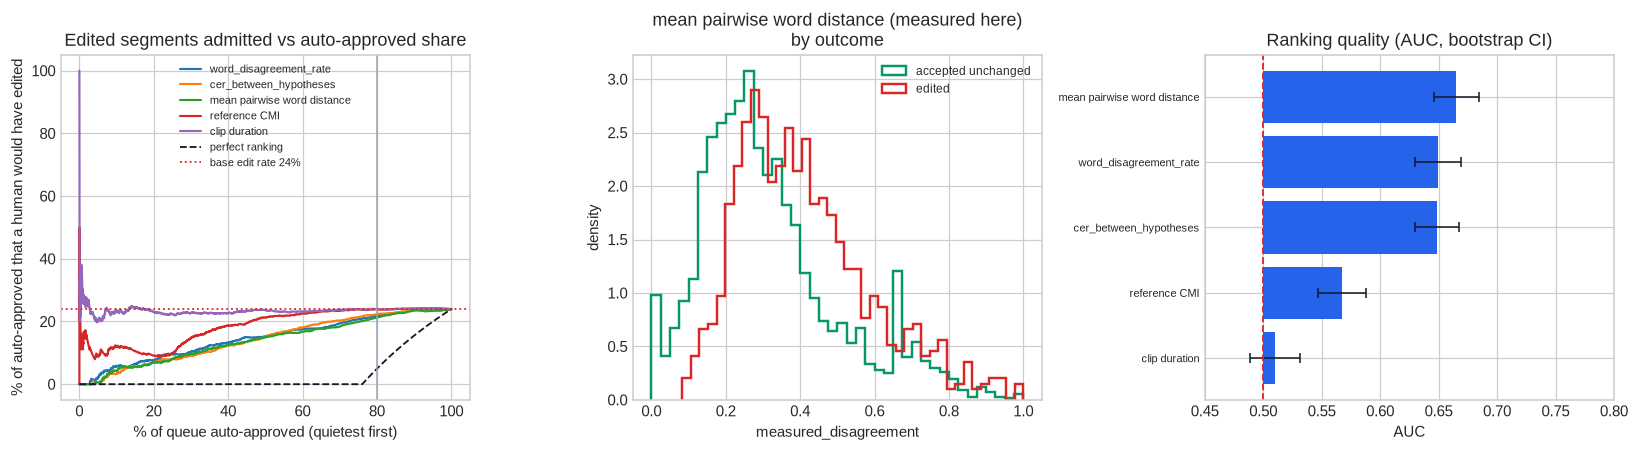

In [19]:
best_label, best_column = max(
    CANDIDATES.items(), key=lambda kv: auc_table.loc[kv[0], "AUC"]
)
scores = np.nan_to_num(signal_frame[best_column].to_numpy(dtype=float))
order = np.argsort(scores, kind="mergesort")  # quietest first
labels_sorted = y[order]

coverage = np.arange(1, len(labels_sorted) + 1) / len(labels_sorted)
admitted = np.cumsum(labels_sorted)  # edited segments wrongly auto-approved
leak_rate = admitted / np.arange(1, len(labels_sorted) + 1)

print(f"Ranking by: {best_label}")
print()
print("Auto-approve the quietest X% of the queue and this is what slips through:")
sweep_rows = []
for target in (0.3, 0.5, 0.6, 0.7, 0.8, 0.9):
    k = int(target * len(labels_sorted)) - 1
    perfect_leak = max(0.0, target - (1 - base_rate)) / target
    sweep_rows.append({
        "auto-approved %": 100 * target,
        "segments": k + 1,
        "edited admitted": int(admitted[k]),
        "leak rate %": 100 * leak_rate[k],
        "leak with perfect ranking %": 100 * perfect_leak,
        "human effort saved %": 100 * target,
    })
sweep = pd.DataFrame(sweep_rows).set_index("auto-approved %")
display(sweep)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for label, column in CANDIDATES.items():
    s = np.nan_to_num(signal_frame[column].to_numpy(dtype=float))
    o = np.argsort(s, kind="mergesort")
    lk = np.cumsum(y[o]) / np.arange(1, len(y) + 1)
    axes[0].plot(100 * coverage, 100 * lk, lw=1.4, label=f"{label.split(' (')[0]}")
perfect = np.maximum(0.0, coverage - (1 - base_rate)) / coverage
axes[0].plot(100 * coverage, 100 * perfect, color="#111827", ls="--", lw=1.2,
             label="perfect ranking")
axes[0].axhline(100 * base_rate, color="#dc2626", ls=":", lw=1.2,
                label=f"base edit rate {100 * base_rate:.0f}%")
axes[0].axvline(80, color="#9ca3af", lw=1)
axes[0].set(title="Edited segments admitted vs auto-approved share",
            xlabel="% of queue auto-approved (quietest first)",
            ylabel="% of auto-approved that a human would have edited")
axes[0].legend(fontsize=7)

for edited, color, name in [(0, "#059669", "accepted unchanged"), (1, "#dc2626", "edited")]:
    subset = signal_frame.loc[signal_frame["is_edited"] == edited, best_column].dropna()
    axes[1].hist(subset, bins=40, density=True, histtype="step", lw=1.6, color=color, label=name)
axes[1].set(title=f"{best_label}\nby outcome", xlabel=best_column, ylabel="density")
axes[1].legend(fontsize=8)

auc_plot = auc_table.sort_values("AUC")
axes[2].barh(range(len(auc_plot)), auc_plot["AUC"] - 0.5, left=0.5,
             xerr=(auc_plot["95% CI high"] - auc_plot["95% CI low"]) / 2,
             color="#2563eb", error_kw={"ecolor": "#111827", "capsize": 3, "lw": 1})
axes[2].axvline(0.5, color="#dc2626", ls="--", lw=1.2)
axes[2].set_yticks(range(len(auc_plot)))
axes[2].set_yticklabels([i.split(" (")[0][:32] for i in auc_plot.index], fontsize=7.5)
axes[2].set(title="Ranking quality (AUC, bootstrap CI)", xlabel="AUC", xlim=(0.45, 0.8))

save_fig(fig, "06_disagreement_gating")
plt.show()

## 10. Seed-system anchoring

Section 8a established that a system's WER on the segments it seeded is *mechanically* near zero
whenever the annotator accepts unchanged — that is arithmetic, not bias, and it is why every
headline number here is seed-excluded.

The behavioural question is different and is what this section tests: **does the annotator work
differently depending on which system seeded them?** If one system's pre-fill is edited less often
than another's, the labels carry that system's habits, and the seed pools are not exchangeable — so
even the seed-excluded comparison is between subtly different populations of segments.

The test is the edit rate by seed system on verified rows, where a human listened regardless.

In [20]:
seed_rows = []
for system, frame in ev.groupby("seed_system_id"):
    verified_rows = frame[frame["verification_tier"] == "verified"]
    row = {
        "seed": system,
        "segments": len(frame),
        "share of corpus %": 100 * len(frame) / len(ev),
        "verified": len(verified_rows),
        "screened %": 100 * (frame["verification_tier"] == "screened").mean(),
        "verified edit rate %": 100 * verified_rows["is_edited"].mean(),
        "mean CMI": frame["cmi_ref"].mean(),
        "mean duration s": frame["duration_seconds"].mean(),
    }
    # How the *other two* systems score inside this seed pool: an unbiased read, because
    # neither of them wrote the label. Comparable across rows of this table.
    for other in SYSTEMS:
        row[f"WER% {other.split('-')[0]}"] = (
            float("nan")
            if other == system
            else 100 * frame[f"{other}|werr"].sum() / frame["ref_words"].sum()
        )
    seed_rows.append(row)
seed_table = pd.DataFrame(seed_rows).set_index("seed")
print("Blank WER cells are the seeded system itself — that number would be measuring the label.")
display(seed_table)

contingency = pd.crosstab(
    ev.loc[ev["verification_tier"] == "verified", "seed_system_id"],
    ev.loc[ev["verification_tier"] == "verified", "is_edited"],
)
if contingency.shape[0] > 1 and contingency.shape[1] > 1:
    chi2, pvalue, dof, _ = st.chi2_contingency(contingency)
    print(f"Edit rate vs seed system (verified rows): chi2 = {chi2:.2f}, dof = {dof}, p = {pvalue:.4f}")
    print("  -> " + ("edit rate depends on which system seeded the segment"
                     if pvalue < 0.05 else "no detectable anchoring effect at p < 0.05"))
else:
    print("Only one seed system present; anchoring cannot be tested from this export.")

# Are the seed pools exchangeable? If the pools differ in what they contain, a seed-excluded
# comparison across systems is still comparing different populations of audio.
pools = ev.groupby("seed_system_id")
print()
print("Are the three seed pools drawn from the same audio? A difference here means the")
print("seed-excluded WERs in section 8a are measured on populations that are not identical.")
pool_check = pools.agg(
    segments=("cmi_ref", "size"),
    mean_cmi=("cmi_ref", "mean"),
    mean_duration_s=("duration_seconds", "mean"),
    mean_disagreement=("word_disagreement_rate", "mean"),
    gold_share_pct=("pot", lambda p: 100 * (p == "gold").mean()),
)
display(pool_check)

groups = [g["cmi_ref"].dropna().to_numpy() for _, g in pools]
if len(groups) > 1:
    stat, pvalue = st.kruskal(*groups)
    print(f"CMI across seed pools: Kruskal-Wallis H = {stat:.2f}, p = {pvalue:.4f} -> "
          + ("pools differ in code-mixing density" if pvalue < 0.05
             else "no detectable difference in code-mixing density"))

print()
print("For completeness, the mechanical effect section 8a corrects for — a system's WER on the")
print("segments it seeded versus everywhere else. The gap is expected and is NOT evidence of")
print("bias; it is what accepting a hypothesis unchanged does to that hypothesis's WER.")
mechanical = pd.DataFrame(
    [
        {
            "system": system,
            "WER% where it seeded": 100
            * ev[ev["seed_system_id"] == system][f"{system}|werr"].sum()
            / max(ev[ev["seed_system_id"] == system]["ref_words"].sum(), 1),
            "WER% elsewhere (used above)": 100
            * ev[ev["seed_system_id"] != system][f"{system}|werr"].sum()
            / max(ev[ev["seed_system_id"] != system]["ref_words"].sum(), 1),
            "n seeded": int((ev["seed_system_id"] == system).sum()),
        }
        for system in SYSTEMS
    ]
).set_index("system")
display(mechanical)

Blank WER cells are the seeded system itself — that number would be measuring the label.


,segments,share of corpus %,verified,screened %,verified edit rate %,mean CMI,mean duration s,WER% elevenlabs,WER% gemini,WER% mai
seed,,,,,,,,,,
elevenlabs-scribe-v2,3017,63.0512,2035,32.5489,25.1597,20.8407,11.5806,NaN,29.1991,30.0252
gemini-3.8-flash,652,13.6259,647,0.7669,26.5842,22.1428,12.1221,25.7839,NaN,30.4871
mai-transcribe-2,1116,23.3229,896,19.7133,19.3080,18.1477,11.5311,21.0396,26.9622,NaN


Edit rate vs seed system (verified rows): chi2 = 14.70, dof = 2, p = 0.0006
  -> edit rate depends on which system seeded the segment

Are the three seed pools drawn from the same audio? A difference here means the
seed-excluded WERs in section 8a are measured on populations that are not identical.


,segments,mean_cmi,mean_duration_s,mean_disagreement,gold_share_pct
seed_system_id,,,,,
elevenlabs-scribe-v2,3017,20.8407,11.5806,0.3876,8.9493
gemini-3.8-flash,652,22.1428,12.1221,0.3700,33.8957
mai-transcribe-2,1116,18.1477,11.5311,0.3189,39.0681


CMI across seed pools: Kruskal-Wallis H = 36.38, p = 0.0000 -> pools differ in code-mixing density

For completeness, the mechanical effect section 8a corrects for — a system's WER on the
segments it seeded versus everywhere else. The gap is expected and is NOT evidence of
bias; it is what accepting a hypothesis unchanged does to that hypothesis's WER.


,WER% where it seeded,WER% elsewhere (used above),n seeded
system,,,
elevenlabs-scribe-v2,3.4242,22.9409,3017
gemini-3.8-flash,6.3414,28.6035,652
mai-transcribe-2,3.6548,30.1154,1116


## 11. Import-time flags, hypothesis shape, and word timings

The flags are set at import from all hypotheses, before anyone looks at the clip. Two questions:
do they predict an edit, and do they predict an *unusable* clip? A flag that fires often and
predicts nothing is queue noise.

The word arrays reduced during the parallel load are also profiled here. `word_span_seconds` is the
total time a hypothesis's words cover; far short of the clip duration is the shape of a transcript
that stopped early, which is what `missed_speech` is trying to catch.

,segments,% of corpus,edit rate when set %,edit rate when clear %,uncertain when set %,lift (pp)
flag,,,,,,
repeated_ngram,12,0.2502,33.3333,17.8265,0.0000,15.5068
script_conflict,472,9.8395,19.7034,17.6647,0.6356,2.0386
missed_speech,656,13.6752,14.1768,18.4496,0.1524,-4.2728
empty_transcript,1,0.0208,0.0000,17.8691,0.0000,-17.8691


Segments with no flag at all: 79.4%


,hypotheses,words,empty_hypotheses,mean_words,words_per_second,mean_span_coverage,median_tail_gap_s,mean_word_conf
system_id,,,,,,,,
elevenlabs-scribe-v2,4797,148450,1,30.9464,2.6621,0.6670,0.2050,NaN
gemini-3.8-flash,4797,151228,0,31.5255,2.7119,0.6159,0.2600,0.5795
mai-transcribe-2,4797,148699,0,30.9983,2.6666,0.6279,0.1260,NaN


  figure -> notebooks/figures/eda_07_flags_and_word_timings.png


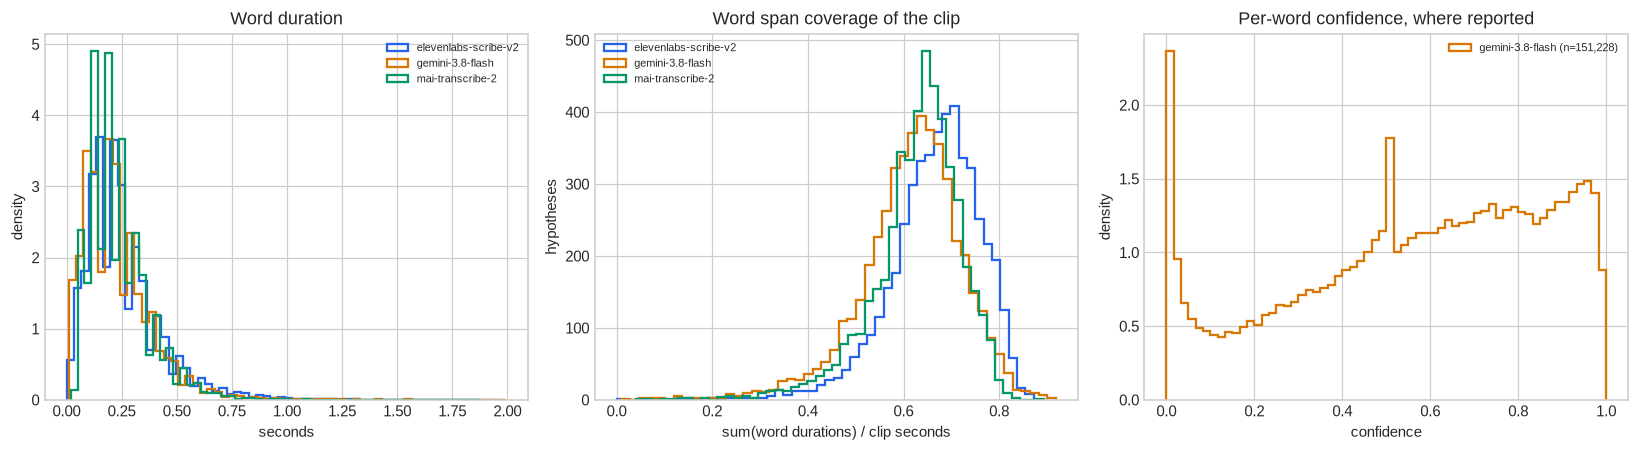

In [21]:
flag_columns = [c for c in seg.columns if c.startswith("flag_")]
flag_rows = []
for column in flag_columns:
    fired = seg[seg[column] == 1]
    quiet = seg[seg[column] == 0]
    flag_rows.append({
        "flag": column.removeprefix("flag_"),
        "segments": len(fired),
        "% of corpus": 100 * len(fired) / len(seg),
        "edit rate when set %": 100 * fired["is_edited"].mean() if len(fired) else np.nan,
        "edit rate when clear %": 100 * quiet["is_edited"].mean() if len(quiet) else np.nan,
        "uncertain when set %": 100 * (fired["disposition"] == "uncertain").mean() if len(fired) else np.nan,
    })
flag_table = pd.DataFrame(flag_rows).set_index("flag")
flag_table["lift (pp)"] = flag_table["edit rate when set %"] - flag_table["edit rate when clear %"]
display(flag_table.sort_values("lift (pp)", ascending=False))
print(f"Segments with no flag at all: {100 * (seg['n_flags'] == 0).mean():.1f}%")

hyp_shape = hyp.merge(
    seg[["duration_seconds", "is_edited", "pot"]], left_on="segment_id", right_index=True
)
hyp_shape["span_coverage"] = hyp_shape["word_span_seconds"] / hyp_shape["duration_seconds"]
hyp_shape["tail_gap_seconds"] = hyp_shape["duration_seconds"] - hyp_shape["last_word_end"]

shape_table = hyp_shape.groupby("system_id").agg(
    hypotheses=("n_words", "size"),
    words=("n_words", "sum"),
    empty_hypotheses=("n_words", lambda s: int((s == 0).sum())),
    mean_words=("n_words", "mean"),
    words_per_second=("n_words", lambda s: s.sum()),
    mean_span_coverage=("span_coverage", "mean"),
    median_tail_gap_s=("tail_gap_seconds", "median"),
    mean_word_conf=("mean_word_conf", "mean"),
)
shape_table["words_per_second"] = shape_table["words_per_second"] / seg["duration_seconds"].sum()
display(shape_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for system in SYSTEMS:
    durations = WORD_DUR[system]
    axes[0].hist(durations[(durations > 0) & (durations < 2)], bins=60, density=True,
                 histtype="step", lw=1.5, color=SYS_COLOR[system], label=system)
axes[0].set(title="Word duration", xlabel="seconds", ylabel="density")
axes[0].legend(fontsize=7)

for system in SYSTEMS:
    subset = hyp_shape.loc[hyp_shape["system_id"] == system, "span_coverage"].clip(0, 1.2)
    axes[1].hist(subset.dropna(), bins=50, histtype="step", lw=1.5, color=SYS_COLOR[system],
                 label=system)
axes[1].set(title="Word span coverage of the clip", xlabel="sum(word durations) / clip seconds",
            ylabel="hypotheses")
axes[1].legend(fontsize=7)

confident = {s: v for s, v in WORD_CONF.items() if len(v)}
if confident:
    for system, values in confident.items():
        axes[2].hist(values, bins=60, density=True, histtype="step", lw=1.5,
                     color=SYS_COLOR[system], label=f"{system} (n={len(values):,})")
    axes[2].set(title="Per-word confidence, where reported", xlabel="confidence", ylabel="density")
    axes[2].legend(fontsize=7)
else:
    axes[2].axis("off")
    axes[2].set_title("No route reports per-word confidence")

save_fig(fig, "07_flags_and_word_timings")
plt.show()

## 12. What the corpus says

Everything below is read straight off the frames above — rerunning the notebook on a newer export
regenerates it.

In [22]:
gold_hours = float(by_pot.loc["gold", "hours"]) if "gold" in by_pot.index else 0.0
train_hours = float(by_pot.loc["train", "hours"]) if "train" in by_pot.index else 0.0
best_system = ci["gold WER %"].idxmin()
best_signal = auc_table["AUC"].idxmax()
best_auc = float(auc_table.loc[best_signal, "AUC"])
ceiling = 1 - base_rate

lines = [
    "SIZE",
    f"  {len(seg):,} labeled segments, {total_hours:.2f} h, {seg['episode_id'].nunique()} episodes.",
    f"  gold {gold_hours:.2f} h of {targets['gold_hours_target']:.0f} h target "
    f"({100 * gold_hours / targets['gold_hours_target']:.0f}%); "
    f"train {train_hours:.2f} h of {targets['train_hours_target']:.0f} h "
    f"({100 * train_hours / targets['train_hours_target']:.0f}%).",
    f"  Gold is {gold_share:.0f}% of the labeled corpus against a "
    f"{100 * targets['gold_max_corpus_fraction']:.0f}% cap.",
    "",
    "LABELING",
    f"  Verified edit rate {100 * base_rate:.1f}% -> auto-approval can never exceed "
    f"{100 * ceiling:.1f}% of the queue without admitting edited segments.",
    f"  {100 * seg['is_screened'].mean():.1f}% of rows were screened, not listened to; "
    f"they are excluded from every signal-quality number above.",
    "",
    "CODE-MIXING",
    f"  {100 * seg['n_latin'].sum() / (seg['n_dev'].sum() + seg['n_latin'].sum()):.1f}% of "
    f"reference tokens are Latin script; mean CMI {seg['cmi_ref'].mean():.1f}.",
    f"  {100 * (seg['n_latin'] == 0).mean():.1f}% of segments contain no English at all, and "
    f"{100 * (seg['n_dev'] == 0).mean():.1f}% contain no Nepali at all —",
    "  two monolingual populations that CMI both scores 0, reported apart from here on.",
    "",
    "ASR",
]
gold_bench = bench.loc["gold (test)"]
for system in ci.sort_values("gold WER %").index:
    lines.append(
        f"  {system:24s} gold WER {ci.loc[system, 'gold WER %']:5.1f}%  "
        f"episode-clustered CI [{ci.loc[system, 'episode CI low']:.1f}-"
        f"{ci.loc[system, 'episode CI high']:.1f}]  "
        f"CER {gold_bench.loc[system, 'CER %']:5.1f}%   (seed-excluded, n={int(ci.loc[system, 'n'])})"
    )
lines.append(f"  Best on gold: {best_system}"
             + ("; its episode-clustered interval is separated from the runner-up." if separated
                else "; its episode-clustered interval OVERLAPS the runner-up, so the ordering is"))
if not separated:
    lines.append(f"  not resolved. The segment-level interval "
                 f"{'says otherwise' if separated_segment else 'agrees'} and is the wrong test: "
                 f"gold holds {n_gold_episodes} recordings,")
    lines.append(f"  not {len(gold):,} independent draws. More distinct recordings is the only "
                 "thing that narrows this.")
lines.append(f"  Quoting the naive table instead would have understated its gold WER by "
             f"{distortion.loc['gold (test)', best_system]:.1f} points.")
worst_script = script_table["delta pts"].idxmax()
if script_table.loc[worst_script, "delta pts"] > 1.0:
    lines += [
        "",
        "SCRIPT, NOT RECOGNITION",
        f"  {worst_script} loses {script_table.loc[worst_script, 'delta pts']:.1f} WER points to "
        f"the {int(script_table.loc[worst_script, 'n there']):,} segments whose reference is",
        f"  >={ENGLISH_DOMINANT}% Latin, where its own output is "
        f"{script_table.loc[worst_script, 'Devanagari % of own output there']:.0f}% Devanagari — "
        "it transliterates English",
        "  rather than mis-hearing it. Dropping that material "
        + ("CHANGES the gold ordering, so the" if order_changes
           else "leaves the gold ordering intact."),
    ]
    if order_changes:
        lines.append("  ranking in section 8a is an artifact of it, not a property of the systems.")
    folded = fold_rates(ev[ev["seed_system_id"] != worst_script], worst_script)
    lines.append(
        f"  Scored on words rather than spelling (8d), it is "
        f"{folded['script-folded %']:.1f}% corpus-wide against a raw "
        f"{folded['raw WER %']:.1f}%, with a floor of {folded['oracle floor %']:.1f}% — so the"
    )
    lines.append("  honest reading is a range, and the raw number stays the one that describes "
                 "the transcript.")

lines += [
    "",
    "DISAGREEMENT AS A GATE",
    f"  Best ranking signal: {best_signal} at AUC {best_auc:.3f} "
    f"(95% CI {auc_table.loc[best_signal, '95% CI low']:.3f}"
    f"-{auc_table.loc[best_signal, '95% CI high']:.3f}).",
    f"  Auto-approving 80% of the queue admits "
    f"{sweep.loc[80.0, 'leak rate %']:.1f}% edited segments; even a perfect ranking admits "
    f"{sweep.loc[80.0, 'leak with perfect ranking %']:.1f}%.",
    "  The binding constraint is the base edit rate, not the ordering.",
    "",
    "THIN STRATA (under the "
    f"{targets['min_stratum_hours']} h floor)",
]
for key, levels in thin.items():
    if levels:
        lines.append(f"  {key}: {', '.join(str(v) for v in levels)}")
print("\n".join(lines))
print()
print("Figures written to notebooks/figures/:")
for path in sorted(FIG_DIR.glob("eda_*.png")):
    print(f"  {path.name}  ({path.stat().st_size / 1024:.0f} KB)")

SIZE
  4,797 labeled segments, 15.49 h, 28 episodes.
  gold 2.80 h of 3 h target (93%); train 12.69 h of 20 h (63%).
  Gold is 18% of the labeled corpus against a 35% cap.

LABELING
  Verified edit rate 24.0% -> auto-approval can never exceed 76.0% of the queue without admitting edited segments.
  25.2% of rows were screened, not listened to; they are excluded from every signal-quality number above.

CODE-MIXING
  34.3% of reference tokens are Latin script; mean CMI 20.3.
  16.1% of segments contain no English at all, and 7.4% contain no Nepali at all —
  two monolingual populations that CMI both scores 0, reported apart from here on.

ASR
  elevenlabs-scribe-v2     gold WER  24.3%  episode-clustered CI [14.5-31.7]  CER  10.8%   (seed-excluded, n=657)
  gemini-3.8-flash         gold WER  29.4%  episode-clustered CI [22.1-36.7]  CER  12.4%   (seed-excluded, n=706)
  mai-transcribe-2         gold WER  35.8%  episode-clustered CI [24.5-61.7]  CER  19.9%   (seed-excluded, n=491)
  Best on 